#Fundamentos de LLMs y Arquitectura Transformer




# 1. Tokenización

Los modelos de lenguaje no procesan texto directamente: procesan **tokens** (subpalabras). La tokenización convierte texto en secuencias de enteros que el modelo puede manejar.

## Algoritmos principales

| Algoritmo | Modelo | Idea clave |
|---|---|---|
| **BPE** (Byte-Pair Encoding) | GPT-2/3/4, LLaMA, Mistral | Fusiona el par de bytes/caracteres más frecuente iterativamente |
| **WordPiece** | BERT, DistilBERT | Como BPE pero maximiza probabilidad del corpus en lugar de frecuencia bruta |
| **SentencePiece** | T5, Gemma, LLaMA-3 | Opera directamente sobre bytes; sin pre-tokenización por espacios |
| **Unigram LM** | AlBERT, T5 | Empieza con vocabulario grande y elimina tokens que menos afectan la log-verosimilitud |
| **Tiktoken (BPE byteable)** | GPT-4, Claude | BPE sobre bytes crudos; robustez total a cualquier Unicode/código |

## Propiedades importantes
- Un carácter español típico → 1–2 tokens
- Un número largo como `123456789` → múltiples tokens
- Código Python → más tokens/carácter que texto inglés
- Los espacios al inicio de palabra son parte del token en GPT-style: `" hello"` ≠ `"hello"`

In [1]:
# ============================================================
#  SETUP
# ============================================================
# !pip install torch matplotlib numpy

import math
import copy
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#e6edf3',       'grid.color': '#21262d',
    'grid.alpha': 0.5,             'font.size': 11,
    'axes.titlesize': 13,          'axes.titleweight': 'bold',
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
})
PALETTE = ['#58a6ff','#ff7b72','#3fb950','#d2a8ff',
           '#ffa657','#79c0ff','#f85149','#56d364']

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
print(f'✅ Setup listo | Device: {device} | PyTorch {torch.__version__}')

✅ Setup listo | Device: cpu | PyTorch 2.10.0+cpu


In [2]:
# ============================================================
#  BPE DESDE CERO
# ============================================================

class BPETokenizer:
    """
    Implementación de Byte-Pair Encoding (BPE) desde cero.
    Algoritmo original de Sennrich et al. 2016.
    """

    def __init__(self):
        self.vocab = {}   # token → id
        self.id_to_token = {}   # id → token
        self.merges = []   # lista de fusiones aprendidas

    def _get_vocab(self, corpus: list[str]) -> dict:
        """Construye vocabulario inicial: caracteres + </w> para fin de palabra."""
        vocab = Counter()
        for texto in corpus:
            for palabra in texto.split():
                # Representar cada palabra como secuencia de chars con </w> al final
                clave = ' '.join(list(palabra)) + ' </w>'
                vocab[clave] += 1
        return dict(vocab)

    def _get_pairs(self, vocab: dict) -> Counter:
        """Cuenta todos los pares de tokens adyacentes en el vocabulario."""
        pares = Counter()
        for palabra, freq in vocab.items():
            simbolos = palabra.split()
            for i in range(len(simbolos) - 1):
                pares[(simbolos[i], simbolos[i+1])] += freq
        return pares

    def _merge_vocab(self, par: tuple, vocab: dict) -> dict:
        """Fusiona el par más frecuente en todas las palabras del vocabulario."""
        nuevo_vocab = {}
        bigram = ' '.join(par)
        reemplazo  = ''.join(par)
        for palabra in vocab:
            nueva_palabra = palabra.replace(bigram, reemplazo)
            nuevo_vocab[nueva_palabra] = vocab[palabra]
        return nuevo_vocab

    def train(self, corpus: list[str], n_merges: int = 50):
        """Aprende n_merges fusiones BPE del corpus."""
        vocab = self._get_vocab(corpus)
        self.merges = []

        for i in range(n_merges):
            pares = self._get_pairs(vocab)
            if not pares:
                break
            mejor_par = pares.most_common(1)[0][0]
            vocab = self._merge_vocab(mejor_par, vocab)
            self.merges.append(mejor_par)

        # Construir vocabulario final
        todos_tokens = set()
        for palabra in vocab:
            for tok in palabra.split():
                todos_tokens.add(tok)
        todos_tokens |= {'<PAD>', '<UNK>', '<BOS>', '<EOS>'}

        self.vocab       = {tok: i for i, tok in enumerate(sorted(todos_tokens))}
        self.id_to_token = {i: tok for tok, i in self.vocab.items()}
        return self

    def tokenize(self, texto: str) -> list[str]:
        """Tokeniza un texto aplicando las fusiones aprendidas."""
        tokens = []
        for palabra in texto.split():
            simbolos = list(palabra) + ['</w>']
            # Aplicar fusiones en orden
            for par in self.merges:
                i = 0
                while i < len(simbolos) - 1:
                    if (simbolos[i], simbolos[i+1]) == par:
                        simbolos = simbolos[:i] + [''.join(par)] + simbolos[i+2:]
                    else:
                        i += 1
            tokens.extend(simbolos)
        return tokens

    def encode(self, texto: str) -> list[int]:
        return [self.vocab.get(t, self.vocab.get('<UNK>', 0))
                for t in self.tokenize(texto)]

    def decode(self, ids: list[int]) -> str:
        return ' '.join(self.id_to_token.get(i, '<UNK>') for i in ids)


# ── Entrenamiento y demo ──────────────────────────────────
corpus = [
    'el gato come pescado',
    'el perro come carne',
    'el gato duerme mucho',
    'la inteligencia artificial aprende de datos',
    'los transformers aprenden representaciones',
    'el modelo de lenguaje genera texto',
]

bpe = BPETokenizer()
bpe.train(corpus, n_merges=30)

texto_test = 'el gato aprende'
tokens     = bpe.tokenize(texto_test)
ids        = bpe.encode(texto_test)

print(f'Texto original : "{texto_test}"')
print(f'Tokens BPE     : {tokens}')
print(f'IDs            : {ids}')
print(f'Tamaño vocab   : {len(bpe.vocab)}')
print(f'\nPrimeras 10 fusiones aprendidas:')
for i, merge in enumerate(bpe.merges[:10], 1):
    print(f'  {i:2d}. {merge[0]} + {merge[1]} → {"" .join(merge)}')

# Comparativa de tokenización
print('\n── Longitud de tokenización (chars vs tokens) ──')
ejemplos = ['gato', 'inteligencia', 'aprende', 'artificial']
for e in ejemplos:
    toks = bpe.tokenize(e)
    print(f'  "{e}" ({len(e)} chars) → {toks} ({len(toks)} tokens)')

Texto original : "el gato aprende"
Tokens BPE     : ['el</w>', 'gato</w>', 'apren', 'de</w>']
IDs            : [18, 25, 7, 14]
Tamaño vocab   : 46

Primeras 10 fusiones aprendidas:
   1. e + </w> → e</w>
   2. o + </w> → o</w>
   3. e + n → en
   4. e + l → el
   5. el + </w> → el</w>
   6. e + r → er
   7. s + </w> → s</w>
   8. a + t → at
   9. m + e</w> → me</w>
  10. a + </w> → a</w>

── Longitud de tokenización (chars vs tokens) ──
  "gato" (4 chars) → ['gato</w>'] (1 tokens)
  "inteligencia" (12 chars) → ['i', 'n', 't', 'el', 'i', 'gen', 'ci', 'a</w>'] (8 tokens)
  "aprende" (7 chars) → ['apren', 'de</w>'] (2 tokens)
  "artificial" (10 chars) → ['a', 'r', 't', 'i', 'f', 'i', 'ci', 'a', 'l', '</w>'] (10 tokens)


---
# 2. Embeddings — Token y Positional Encoding

Los tokens (enteros) se convierten en vectores densos mediante una **tabla de embeddings**. Pero los vectores de tokens no tienen información de posición: dos frases con las mismas palabras en distinto orden producirían los mismos embeddings. El **positional encoding** resuelve esto.

## Positional Encoding Sinusoidal (original, Vaswani 2017)

$$PE_{(pos, 2i)}   = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Cada posición recibe un vector único. Las dimensiones pares usan seno, las impares coseno. Las frecuencias van de muy rápidas (dimensión 0) a muy lentas (última dimensión), creando una especie de «reloj binario» analógico.

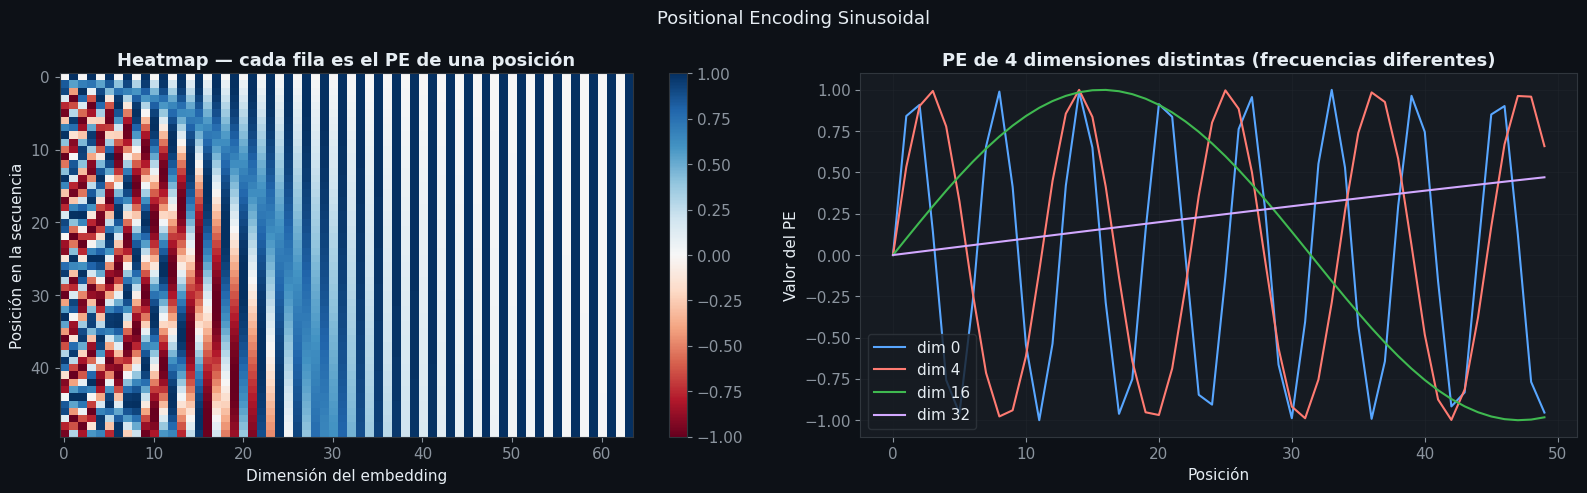

Similitud coseno entre posiciones:
  pos(0) · pos(5)  = 0.7345
  pos(5) · pos(10) = 0.7345
  pos(10)· pos(15) = 0.7345
  pos(0) · pos(49) = 0.4754  (posiciones lejanas son ortogonales)


In [3]:
# ============================================================
#  EMBEDDINGS Y POSITIONAL ENCODING
# ============================================================

class TokenEmbedding(nn.Module):
    """Tabla de embeddings con escalado por sqrt(d_model)."""
    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.d_model   = d_model
        # Inicialización estándar
        nn.init.normal_(self.embedding.weight, mean=0, std=d_model**-0.5)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Escalar por sqrt(d_model) para que el PE no domine
        return self.embedding(x) * math.sqrt(self.d_model)


class SinusoidalPE(nn.Module):
    """Positional Encoding sinusoidal (Vaswani et al. 2017)."""
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Construir la tabla PE de forma vectorizada
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()          # (max_len, 1)
        div = torch.exp(torch.arange(0, d_model, 2).float() *
                        -(math.log(10000.0) / d_model))            # (d_model/2,)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))                # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


# ── Visualizar el PE sinusoidal ───────────────────────────
d_model = 64
max_len = 50

pe_layer = SinusoidalPE(d_model, max_len, dropout=0.0)
pe_matrix = pe_layer.pe.squeeze(0).numpy()  # (max_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Positional Encoding Sinusoidal', fontsize=13)

im = axes[0].imshow(pe_matrix, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_xlabel('Dimensión del embedding')
axes[0].set_ylabel('Posición en la secuencia')
axes[0].set_title('Heatmap — cada fila es el PE de una posición')
plt.colorbar(im, ax=axes[0])

for i, dim in enumerate([0, 4, 16, 32]):
    axes[1].plot(pe_matrix[:, dim], label=f'dim {dim}', color=PALETTE[i])
axes[1].set_xlabel('Posición')
axes[1].set_ylabel('Valor del PE')
axes[1].set_title('PE de 4 dimensiones distintas (frecuencias diferentes)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('pe_sinusoidal.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── Propiedad clave: diferencia entre posiciones es constante ──
pe_0 = pe_matrix[0]
pe_5 = pe_matrix[5]
pe_10 = pe_matrix[10]
pe_15 = pe_matrix[15]

cos_sim = lambda a, b: np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)
print('Similitud coseno entre posiciones:')
print(f'  pos(0) · pos(5)  = {cos_sim(pe_0, pe_5):.4f}')
print(f'  pos(5) · pos(10) = {cos_sim(pe_5, pe_10):.4f}')
print(f'  pos(10)· pos(15) = {cos_sim(pe_10, pe_15):.4f}')
print(f'  pos(0) · pos(49) = {cos_sim(pe_0, pe_matrix[49]):.4f}  (posiciones lejanas son ortogonales)')

---
# 3. Self-Attention — Mecánica e Implementación

## La intuición
Cada token «pregunta» al resto: *¿qué partes de la secuencia son relevantes para mí?*
- **Query (Q)**: la pregunta que hace el token actual
- **Key (K)**: la «etiqueta» que expone cada token al ser consultado
- **Value (V)**: la información que un token comparte si es relevante

## Fórmula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

- $Q, K, V \in \mathbb{R}^{n \times d_k}$ obtenidos proyectando la entrada $X$ con $W_Q, W_K, W_V$
- $\sqrt{d_k}$: factor de escala que estabiliza los gradientes (sin él el softmax satura)
- Complejidad: $O(n^2 d_k)$ — el cuello de botella cuadrático en longitud de secuencia

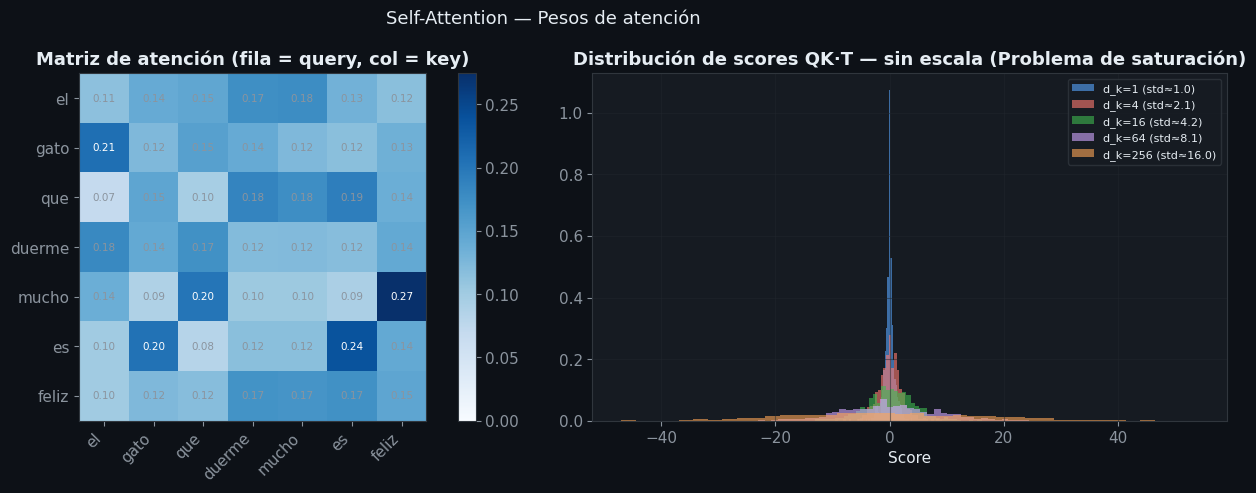

Output shape: torch.Size([1, 7, 32])  (batch, seq, d_model)


In [4]:
# ============================================================
#  SELF-ATTENTION DESDE CERO
# ============================================================

def scaled_dot_product_attention(
        Q: torch.Tensor,
        K: torch.Tensor,
        V: torch.Tensor,
        mask: torch.Tensor | None = None,
        dropout: float = 0.0) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Scaled Dot-Product Attention.

    Q, K, V : (batch, heads, seq, d_k)
    mask    : (batch, 1, seq_q, seq_k)  — True donde ENMASCARAR

    Retorna
    -------
    output  : (batch, heads, seq, d_v)
    weights : (batch, heads, seq_q, seq_k)  — pesos de atención
    """
    d_k    = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)  # (B, H, Sq, Sk)

    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))

    weights = F.softmax(scores, dim=-1)
    weights = F.dropout(weights, p=dropout, training=True) if dropout > 0 else weights

    output = torch.matmul(weights, V)   # (B, H, Sq, d_v)
    return output, weights


class SingleHeadAttention(nn.Module):
    """Self-Attention de una sola cabeza — versión pedagógica."""

    def __init__(self, d_model: int, d_k: int | None = None):
        super().__init__()
        self.d_k = d_k or d_model
        self.W_Q = nn.Linear(d_model, self.d_k, bias=False)
        self.W_K = nn.Linear(d_model, self.d_k, bias=False)
        self.W_V = nn.Linear(d_model, self.d_k, bias=False)
        self.W_O = nn.Linear(self.d_k, d_model, bias=False)

    def forward(self, x: torch.Tensor,
                mask: torch.Tensor | None = None) -> tuple:
        B, T, _ = x.shape
        Q = self.W_Q(x).unsqueeze(1)  # (B, 1, T, d_k)
        K = self.W_K(x).unsqueeze(1)
        V = self.W_V(x).unsqueeze(1)
        out, weights = scaled_dot_product_attention(Q, K, V, mask)
        out = out.squeeze(1)           # (B, T, d_k)
        return self.W_O(out), weights.squeeze(1)


# ── Demo: attention sobre una frase ──────────────────────
torch.manual_seed(42)
tokens_demo = ['el', 'gato', 'que', 'duerme', 'mucho', 'es', 'feliz']
T, D = len(tokens_demo), 32

x_demo  = torch.randn(1, T, D)   # (batch=1, seq=7, d_model=32)
sha     = SingleHeadAttention(D, d_k=16)
out, w  = sha(x_demo)

weights_np = w.detach().squeeze(0).numpy()  # (T, T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Self-Attention — Pesos de atención', fontsize=13)

im = axes[0].imshow(weights_np, cmap='Blues', vmin=0)
axes[0].set_xticks(range(T)); axes[0].set_xticklabels(tokens_demo, rotation=45, ha='right')
axes[0].set_yticks(range(T)); axes[0].set_yticklabels(tokens_demo)
axes[0].set_title('Matriz de atención (fila = query, col = key)')
plt.colorbar(im, ax=axes[0])
for i in range(T):
    for j in range(T):
        axes[0].text(j, i, f'{weights_np[i,j]:.2f}', ha='center', va='center',
                    fontsize=7.5, color='white' if weights_np[i,j] > 0.2 else '#8b949e')

# Comparar scores con y sin escala sqrt(d_k)
d_k_vals = [1, 4, 16, 64, 256]
q = torch.randn(1000, 16)
k = torch.randn(1000, 16)
for d_k_test, color in zip(d_k_vals, PALETTE[:5]):
    scores_raw = (q * k).sum(dim=-1)  # dot products
    # simular cómo varía la varianza con d_k
    q_d = torch.randn(1000, d_k_test)
    k_d = torch.randn(1000, d_k_test)
    scores_d = (q_d * k_d).sum(dim=-1)
    axes[1].hist(scores_d.numpy(), bins=40, alpha=0.6, density=True,
                 color=color, label=f'd_k={d_k_test} (std≈{scores_d.std():.1f})')
axes[1].set_title('Distribución de scores QK·T — sin escala (Problema de saturación)')
axes[1].set_xlabel('Score'); axes[1].legend(fontsize=8); axes[1].grid(True)

plt.tight_layout()
plt.savefig('self_attention.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Output shape: {out.shape}  (batch, seq, d_model)')

---
# 4. Multi-Head Attention

Una sola cabeza solo puede atender a **un subespacio** de relaciones. Multi-Head Attention ejecuta $h$ atenciones en paralelo sobre proyecciones distintas, y concatena los resultados:

$$\text{MHA}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$$
$$\text{head}_i = \text{Attention}(Q W_i^Q,\; K W_i^K,\; V W_i^V)$$

Cada cabeza tiene $d_k = d_{model}/h$ dimensiones. En total, los parámetros son idénticos a una atención simple de dimensión $d_{model}$, pero con mayor expresividad al capturar distintos tipos de relaciones.

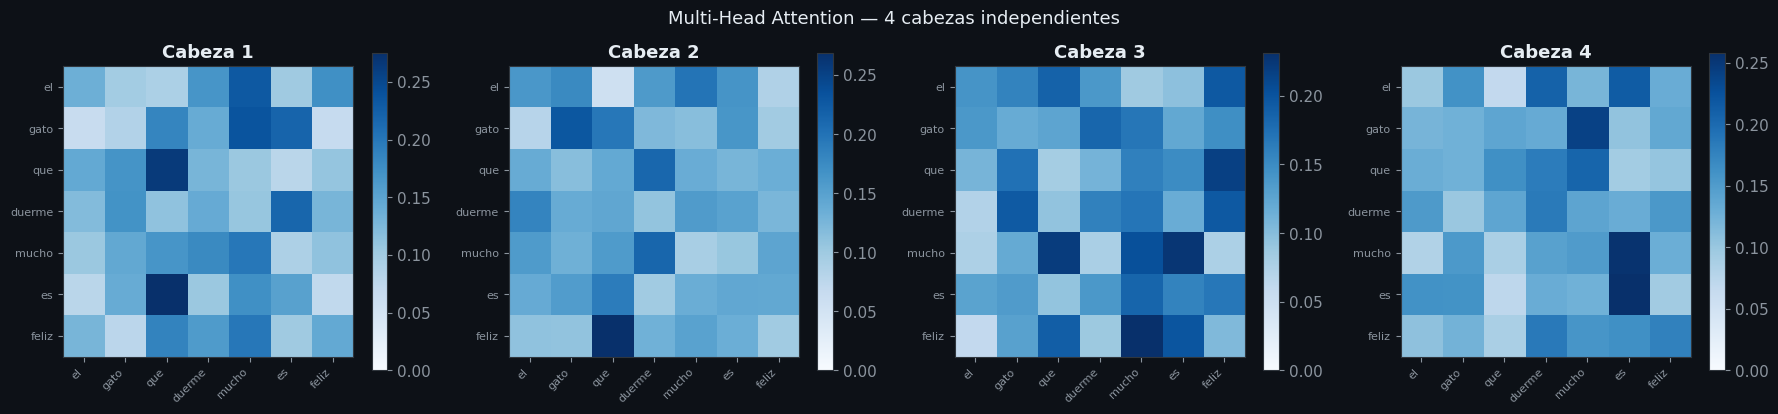

Cada cabeza ve el mismo input pero aprende a atender a distintos patrones.


In [5]:
# ============================================================
#  MULTI-HEAD ATTENTION DESDE CERO
# ============================================================

class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention (Vaswani et al. 2017).
    Implementación eficiente: proyecta todo junto y reordena dimensiones.
    """

    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model debe ser divisible entre n_heads'
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.dropout = dropout

        # Una sola proyección para Q, K, V y salida
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, T, d_model) → (B, n_heads, T, d_k)"""
        B, T, _ = x.shape
        return x.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

    def forward(self,
                query: torch.Tensor,
                key:   torch.Tensor,
                value: torch.Tensor,
                mask:  torch.Tensor | None = None) -> tuple:
        B, T_q, _ = query.shape

        # Proyectar y dividir en cabezas
        Q = self.split_heads(self.W_Q(query))  # (B, H, T_q, d_k)
        K = self.split_heads(self.W_K(key))
        V = self.split_heads(self.W_V(value))

        # Atención escalada
        out, weights = scaled_dot_product_attention(
            Q, K, V, mask,
            dropout=self.dropout if self.training else 0.0
        )

        # Concatenar cabezas y proyectar
        out = out.transpose(1, 2).contiguous().view(B, T_q, self.d_model)
        return self.W_O(out), weights


# ── Visualizar cada cabeza ────────────────────────────────
torch.manual_seed(7)
D, H = 64, 4
T    = len(tokens_demo)
mha  = MultiHeadAttention(D, H, dropout=0.0)
x_in = torch.randn(1, T, D)
out_mha, w_mha = mha(x_in, x_in, x_in)  # self-attention

# w_mha: (1, H, T, T)
fig, axes = plt.subplots(1, H, figsize=(18, 4))
fig.suptitle(f'Multi-Head Attention — {H} cabezas independientes', fontsize=13)

for h in range(H):
    w_h = w_mha[0, h].detach().numpy()
    im  = axes[h].imshow(w_h, cmap='Blues', vmin=0, vmax=w_h.max())
    axes[h].set_title(f'Cabeza {h+1}')
    axes[h].set_xticks(range(T)); axes[h].set_xticklabels(tokens_demo, rotation=45, ha='right', fontsize=8)
    axes[h].set_yticks(range(T)); axes[h].set_yticklabels(tokens_demo, fontsize=8)
    plt.colorbar(im, ax=axes[h])

plt.tight_layout()
plt.savefig('mha_heads.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Cada cabeza ve el mismo input pero aprende a atender a distintos patrones.')

---
# 5. Feed-Forward, LayerNorm y Residual Connections

Cada bloque transformer tiene dos sub-capas: **Multi-Head Attention** y una **Feed-Forward Network (FFN)**. Ambas están envueltas en conexiones residuales y normalizadas.

## Feed-Forward Network
$$\text{FFN}(x) = \text{ReLU}(x W_1 + b_1) W_2 + b_2$$

La expansión típica es $d_{ff} = 4 \times d_{model}$. La FFN se aplica **posición a posición** (igual para todos los tokens, sin interacción entre ellos — eso lo hace la atención).

## LayerNorm
$$\text{LN}(x) = \frac{x - \mu}{\sigma + \epsilon} \cdot \gamma + \beta$$

Normaliza sobre las características (no sobre el batch). Estabiliza el entrenamiento.

## Post-LN vs Pre-LN
- **Post-LN** (original): `LN(x + Sublayer(x))` — inestable en modelos grandes
- **Pre-LN** (moderno): `x + Sublayer(LN(x))` — más estable, el estándar actual

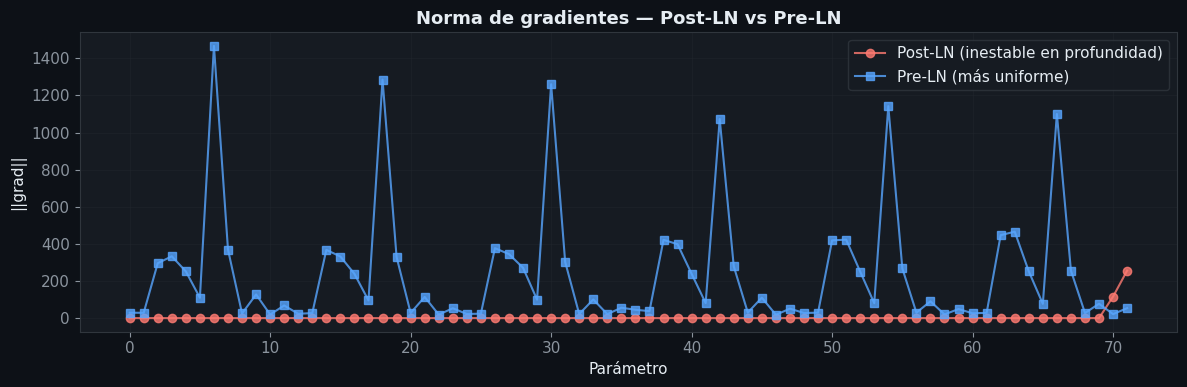

In [7]:
# ============================================================
#  FFN, LAYERNORM, RESIDUAL — Bloques del transformer
# ============================================================

class FeedForward(nn.Module):
    """
    FFN original con ReLU.
    Se aplica posición a posición: cada token se transforma independientemente.
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x): return self.net(x)


class PostLNBlock(nn.Module):
    """Bloque original (Vaswani 2017): LN después de la sublayer."""
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn  = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        attn_out, w = self.attn(x, x, x, mask)
        x = self.norm1(x + attn_out)   # Post-LN: normalize after residual
        x = self.norm2(x + self.ffn(x))
        return x, w


class PreLNBlock(nn.Module):
    """Bloque moderno (GPT-2+, LLaMA): LN antes de la sublayer."""
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn   = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # Pre-LN: normalize before sublayer, add residual after
        attn_out, w = self.attn(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x, w


# ── Comparativa: gradiente en bloque Post-LN vs Pre-LN ───
torch.manual_seed(42)
D, H, FF = 64, 4, 256
T_test = 16

def medir_gradientes(block_class, n_capas=6):
    bloques = [block_class(D, H, FF, dropout=0.0) for _ in range(n_capas)]
    x = torch.randn(2, T_test, D, requires_grad=True)
    h = x
    for bloque in bloques:
        h, _ = bloque(h)
    loss = h.sum()
    loss.backward()
    grad_norms = []
    for bloque in bloques:
        for p in bloque.parameters():
            if p.grad is not None:
                grad_norms.append(p.grad.norm().item())
    return grad_norms

grads_postln = medir_gradientes(PostLNBlock)
grads_preln  = medir_gradientes(PreLNBlock)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(grads_postln, 'o-', color=PALETTE[1], label='Post-LN (inestable en profundidad)', alpha=0.8)
ax.plot(grads_preln,  's-', color=PALETTE[0], label='Pre-LN (más uniforme)', alpha=0.8)
ax.set_title('Norma de gradientes — Post-LN vs Pre-LN')
ax.set_xlabel('Parámetro'); ax.set_ylabel('||grad||')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig('preln_postln.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 6. Encoder Completo

El **encoder** transforma una secuencia de tokens en representaciones contextuales ricas. Cada token «ve» todos los demás (atención bidireccional). Ejemplo: BERT usa solo encoder.

```
Input tokens → Token Embedding + Positional Encoding
    ↓
[EncoderBlock_1] → [EncoderBlock_2] → ... → [EncoderBlock_N]
    ↓
Representaciones contextuales (misma forma que la entrada)
```

── Encoder completado ──
  Input  : torch.Size([2, 10])         (batch, seq)
  Output : torch.Size([2, 10, 64])  (batch, seq, d_model)
  Capas  : 3 capas de atención
  Params : 155,712


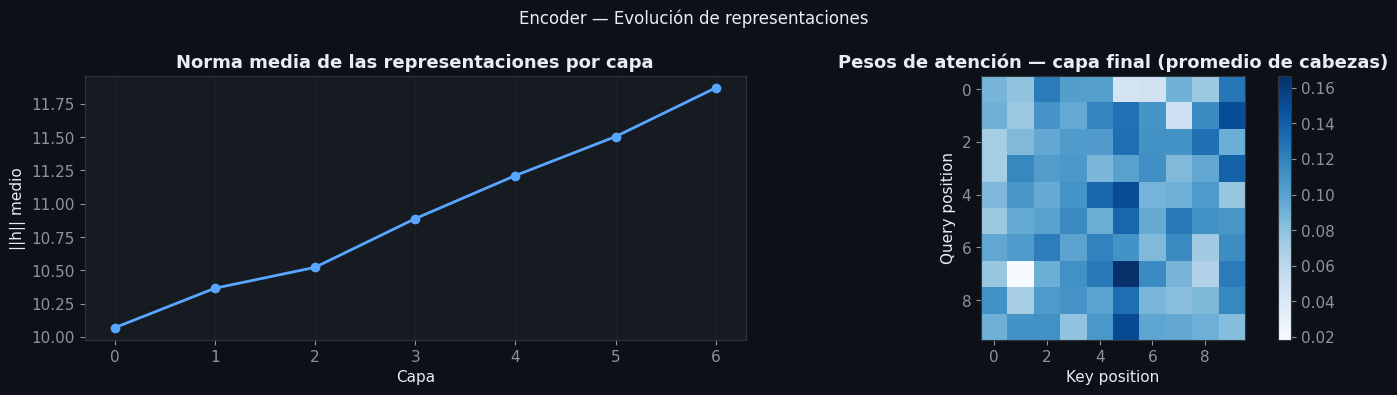

In [11]:
# ============================================================
#  ENCODER COMPLETO
# ============================================================

class Encoder(nn.Module):
    """
    Encoder del Transformer original.
    N capas de (Self-Attention + FFN) con conexiones residuales.
    """

    def __init__(self, vocab_size: int, d_model: int, n_heads: int,
                  d_ff: int, n_layers: int, max_len: int = 512,
                  dropout: float = 0.1):
        super().__init__()
        self.token_emb = TokenEmbedding(vocab_size, d_model)
        self.pos_enc   = SinusoidalPE(d_model, max_len, dropout)
        self.layers    = nn.ModuleList([
            PreLNBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.norm_final = nn.LayerNorm(d_model)  # Pre-LN requiere LN final

    def make_padding_mask(self, src: torch.Tensor,
                           pad_idx: int = 0) -> torch.Tensor:
        """Máscara para ignorar tokens de padding. Shape: (B, 1, 1, T)"""
        return (src == pad_idx).unsqueeze(1).unsqueeze(2)

    def forward(self, src: torch.Tensor,
                src_mask: torch.Tensor | None = None) -> dict:
        # src: (B, T) — IDs de tokens
        x = self.pos_enc(self.token_emb(src))  # (B, T, D)
        all_weights = []
        for layer in self.layers:
            x, w = layer(x, src_mask)
            all_weights.append(w)
        x = self.norm_final(x)
        return {'output': x, 'attention_weights': all_weights}


# ── Prueba del encoder ────────────────────────────────────
torch.manual_seed(42)
enc = Encoder(vocab_size=100, d_model=64, n_heads=4,
               d_ff=256, n_layers=3, max_len=50)

src_ids = torch.randint(1, 100, (2, 10))  # (batch=2, seq=10)
result  = enc(src_ids)

print('── Encoder completado ──')
print(f'  Input  : {src_ids.shape}         (batch, seq)')
print(f'  Output : {result["output"].shape}  (batch, seq, d_model)')
print(f'  Capas  : {len(result["attention_weights"])} capas de atención')
print(f'  Params : {sum(p.numel() for p in enc.parameters()):,}')

# ── Visualizar cómo evolucionan las representaciones ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Encoder — Evolución de representaciones', fontsize=12)

# Norma de los vectores por capa
enc_eval = Encoder(vocab_size=100, d_model=64, n_heads=4, d_ff=256, n_layers=6)
enc_eval.eval()
with torch.no_grad():
    # Conectar al forward para ver representaciones intermedias
    x_norm_track = enc_eval.pos_enc(enc_eval.token_emb(src_ids))
    norms_by_layer = [x_norm_track.norm(dim=-1).mean().item()]
    for layer in enc_eval.layers:
        x_norm_track, _ = layer(x_norm_track)
        norms_by_layer.append(x_norm_track.norm(dim=-1).mean().item())

axes[0].plot(norms_by_layer, 'o-', color=PALETTE[0], lw=2)
axes[0].set_xlabel('Capa'); axes[0].set_ylabel('||h|| medio')
axes[0].set_title('Norma media de las representaciones por capa')
axes[0].grid(True)

# Heatmap de la última capa de atención
w_last = result['attention_weights'][-1][0].mean(dim=0).detach().numpy()
im = axes[1].imshow(w_last, cmap='Blues')
axes[1].set_title('Pesos de atención — capa final (promedio de cabezas)')
axes[1].set_xlabel('Key position'); axes[1].set_ylabel('Query position')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('encoder_layers.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 7. Decoder Completo con Masked Attention

El **decoder** genera tokens uno a uno (autorregresivo). Tiene **tres** sublayers:

1. **Masked Self-Attention**: el token en posición $t$ solo puede atender a posiciones $\leq t$ (máscara causal). Evita «ver el futuro».
2. **Cross-Attention**: atiende a las salidas del encoder. Queries vienen del decoder, Keys y Values del encoder.
3. **FFN**: igual que en el encoder.

En los LLMs modernos (GPT, LLaMA...) solo se usa el **decoder** — no hay encoder ni cross-attention.

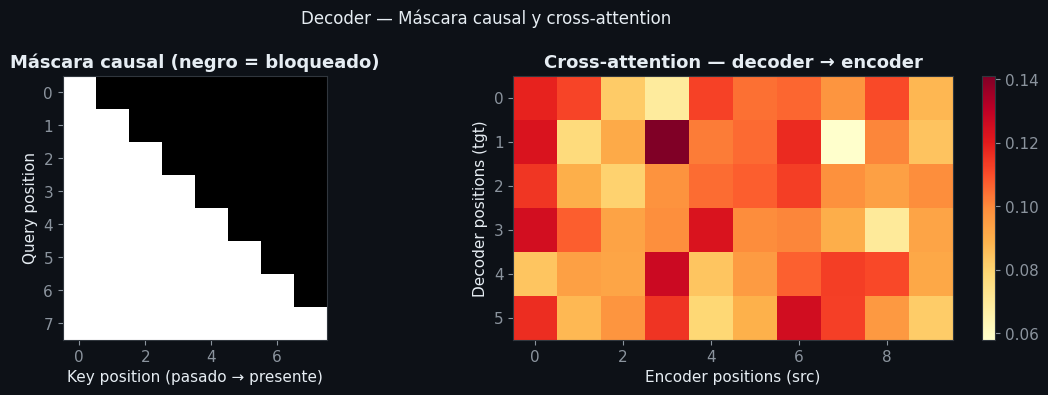

Logits shape: torch.Size([1, 6, 100])  (batch, tgt_len, vocab_size)


In [9]:
# ============================================================
#  DECODER COMPLETO
# ============================================================

def make_causal_mask(T: int, device='cpu') -> torch.Tensor:
    """
    Máscara causal (triangular superior) para el decoder.
    True = posición ENMASCARADA (no puede ver).
    Forma: (1, 1, T, T)
    """
    mask = torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()
    return mask.unsqueeze(0).unsqueeze(0)  # (1, 1, T, T)


class DecoderBlock(nn.Module):
    """Bloque del decoder: Masked Self-Attn + Cross-Attn + FFN (Pre-LN)."""

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, n_heads, dropout)  # masked
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)  # sobre encoder
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor,
                enc_output: torch.Tensor,
                src_mask: torch.Tensor | None = None,
                tgt_mask: torch.Tensor | None = None) -> tuple:
        # 1. Masked Self-Attention (solo ve el pasado)
        x2, w_self  = self.self_attn(self.norm1(x), self.norm1(x),
                                      self.norm1(x), tgt_mask)
        x = x + x2

        # 2. Cross-Attention (consulta al encoder)
        x2, w_cross = self.cross_attn(self.norm2(x), enc_output,
                                       enc_output, src_mask)
        x = x + x2

        # 3. FFN
        x = x + self.ffn(self.norm3(x))
        return x, w_self, w_cross


class Decoder(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, n_heads: int,
                  d_ff: int, n_layers: int, max_len: int = 512,
                  dropout: float = 0.1):
        super().__init__()
        self.token_emb  = TokenEmbedding(vocab_size, d_model)
        self.pos_enc = SinusoidalPE(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            DecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm_final = nn.LayerNorm(d_model)
        self.proj = nn.Linear(d_model, vocab_size)  # proyección final al vocab

    def forward(self, tgt: torch.Tensor,
                enc_output: torch.Tensor,
                src_mask: torch.Tensor | None = None) -> dict:
        B, T = tgt.shape
        tgt_mask = make_causal_mask(T, tgt.device)
        x = self.pos_enc(self.token_emb(tgt))
        cross_attn_all = []
        for layer in self.layers:
            x, _, w_cross = layer(x, enc_output, src_mask, tgt_mask)
            cross_attn_all.append(w_cross)
        x     = self.norm_final(x)
        logits = self.proj(x)   # (B, T, vocab_size)
        return {'logits': logits, 'cross_attention': cross_attn_all}


# ── Visualizar máscara causal ─────────────────────────────
T_vis = 8
mask_vis = make_causal_mask(T_vis).squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Decoder — Máscara causal y cross-attention', fontsize=12)

im0 = axes[0].imshow(mask_vis.astype(float), cmap='Greys')
axes[0].set_title('Máscara causal (negro = bloqueado)')
axes[0].set_xlabel('Key position (pasado → presente)')
axes[0].set_ylabel('Query position')
for i in range(T_vis):
    for j in range(T_vis):
        axes[0].text(j, i, '✓' if not mask_vis[i,j] else '✗',
                    ha='center', va='center', fontsize=10,
                    color='black' if mask_vis[i,j] else 'white')

# Cross-attention demo
dec = Decoder(vocab_size=100, d_model=64, n_heads=4, d_ff=256, n_layers=2)
dec.eval()
enc_out = torch.randn(1, 10, 64)  # salida del encoder (batch, src_len, d_model)
tgt_ids = torch.randint(1, 100, (1, 6))
with torch.no_grad():
    dec_result = dec(tgt_ids, enc_out)

w_cross = dec_result['cross_attention'][-1][0].mean(0).numpy()  # (tgt, src)
im1 = axes[1].imshow(w_cross, cmap='YlOrRd')
axes[1].set_title('Cross-attention — decoder → encoder')
axes[1].set_xlabel('Encoder positions (src)')
axes[1].set_ylabel('Decoder positions (tgt)')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig('decoder_masks.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Logits shape: {dec_result["logits"].shape}  (batch, tgt_len, vocab_size)')

---
# 8. Transformer Completo — Entrenado en Tarea Toy

Ensamblamos encoder + decoder y entrenamos en una tarea de **reversión de secuencias**: dado `[1, 2, 3, 4, 5]`, producir `[5, 4, 3, 2, 1]`. Es una tarea sintética que verifica que el transformer ha aprendido correctamente.

Parámetros: 236,052
Entrenando...
  Epoch   5 | Loss=0.8507 | Acc=76.16%
  Epoch  10 | Loss=0.1732 | Acc=95.39%
  Epoch  15 | Loss=0.0867 | Acc=97.58%
  Epoch  20 | Loss=0.0544 | Acc=98.56%


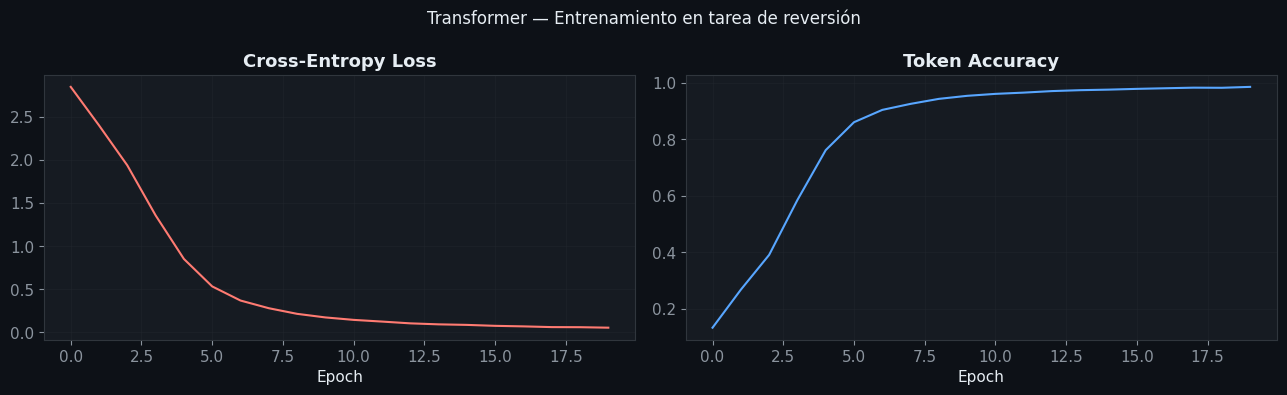


Input    : [9, 9, 14, 4, 17, 12, 3, 9]
Expected : [9, 3, 12, 17, 4, 14, 9, 9]
Generated: [9, 3, 12, 17, 4, 14, 9, 9]
Correcto : True


In [12]:
# ============================================================
#  TRANSFORMER COMPLETO — Encoder + Decoder
# ============================================================

class Transformer(nn.Module):
    def __init__(self, vocab_size: int, d_model: int = 128,
                  n_heads: int = 4, d_ff: int = 512,
                  n_enc_layers: int = 3, n_dec_layers: int = 3,
                  max_len: int = 100, dropout: float = 0.1):
        super().__init__()
        self.encoder = Encoder(vocab_size, d_model, n_heads,
                                d_ff, n_enc_layers, max_len, dropout)
        self.decoder = Decoder(vocab_size, d_model, n_heads,
                                d_ff, n_dec_layers, max_len, dropout)

    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        src_mask = self.encoder.make_padding_mask(src)
        enc_out = self.encoder(src, src_mask)['output']
        dec_out = self.decoder(tgt, enc_out, src_mask)
        return dec_out['logits']


# ── Tarea toy: revertir secuencias ───────────────────────
PAD, BOS, EOS = 0, 1, 2
VOCAB_SIZE = 20

class ReverseDataset(Dataset):
    def __init__(self, n: int = 2000, seq_len: int = 8):
        self.data = []
        for _ in range(n):
            seq = torch.randint(3, VOCAB_SIZE, (seq_len,))
            src = seq
            tgt = torch.cat([torch.tensor([BOS]), seq.flip(0)])  # BOS + reverso
            lbl = torch.cat([seq.flip(0), torch.tensor([EOS])])  # reverso + EOS
            self.data.append((src, tgt, lbl))

    def __len__(self)  : return len(self.data)
    def __getitem__(self, i): return self.data[i]


# Entrenamiento
dataset = ReverseDataset(n=3000, seq_len=8)
loader = DataLoader(dataset, batch_size=64, shuffle=True)
model = Transformer(VOCAB_SIZE, d_model=64, n_heads=4, d_ff=256,
                         n_enc_layers=2, n_dec_layers=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, betas=(0.9, 0.98))
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

print(f'Parámetros: {sum(p.numel() for p in model.parameters()):,}')
print('Entrenando...')

hist_loss, hist_acc = [], []

for epoch in range(20):
    model.train()
    epoch_loss, epoch_acc, n_batches = 0, 0, 0
    for src, tgt, lbl in loader:
        src, tgt, lbl = src.to(device), tgt.to(device), lbl.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt)              # (B, T, V)
        loss = criterion(logits.view(-1, VOCAB_SIZE), lbl.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds   = logits.argmax(-1)
        correct = (preds == lbl).float().mean().item()
        epoch_loss += loss.item()
        epoch_acc  += correct
        n_batches  += 1

    avg_loss = epoch_loss / n_batches
    avg_acc  = epoch_acc  / n_batches
    hist_loss.append(avg_loss)
    hist_acc.append(avg_acc)
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:3d} | Loss={avg_loss:.4f} | Acc={avg_acc:.2%}')

# Visualizar entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Transformer — Entrenamiento en tarea de reversión', fontsize=12)
axes[0].plot(hist_loss, color=PALETTE[1]); axes[0].set_title('Cross-Entropy Loss')
axes[0].set_xlabel('Epoch'); axes[0].grid(True)
axes[1].plot(hist_acc, color=PALETTE[0]);  axes[1].set_title('Token Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].grid(True)
plt.tight_layout()
plt.savefig('transformer_training.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Test de inferencia
model.eval()
src_test = torch.randint(3, VOCAB_SIZE, (1, 8)).to(device)
expected = src_test.flip(1)[0].tolist()

# Greedy decoding
generated = [BOS]
with torch.no_grad():
    enc_out = model.encoder(src_test)['output']
    for _ in range(8):
        tgt_so_far = torch.tensor([generated]).to(device)
        logits = model.decoder(tgt_so_far, enc_out)['logits']
        next_tok = logits[0, -1].argmax().item()
        generated.append(next_tok)
        if next_tok == EOS: break

print(f'\nInput    : {src_test[0].tolist()}')
print(f'Expected : {expected}')
print(f'Generated: {generated[1:]}')
print(f'Correcto : {generated[1:1+len(expected)] == expected}')

---
# 9. Variantes de Positional Encoding

El PE sinusoidal original tiene limitaciones en contextos largos. Estas son las alternativas modernas:

| Técnica | Modelo | Idea | Extrapolación |
|---|---|---|---|
| **Sinusoidal** | Transformer original | Funciones sin/cos fijas | Limitada |
| **Learned** | BERT, GPT-2 | Embeddings de posición entrenables | No extrapola |
| **ALiBi** | BLOOM, MPT | Resta penalidad lineal proporcional a la distancia | Buena |
| **RoPE** | LLaMA, GPT-NeoX, Qwen | Rota los vectores Q/K según la posición | Muy buena con YaRN |
| **NoPE** | Algunos modelos | Sin PE explícito — el modelo aprende implícitamente | Variable |

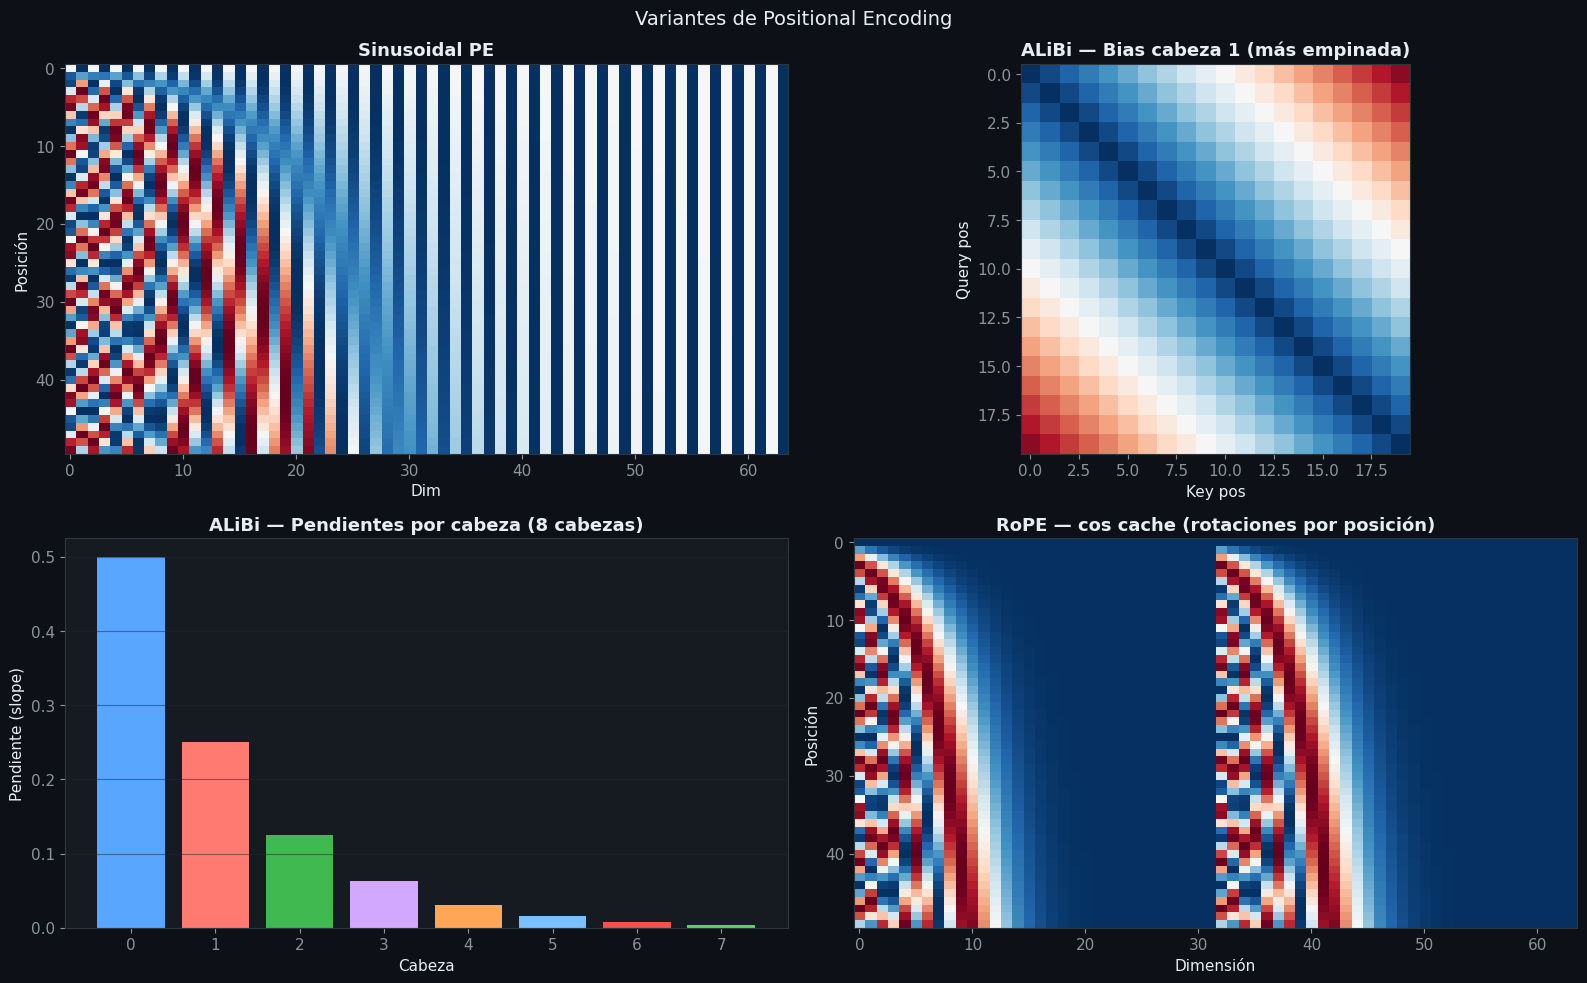

RoPE — Propiedad: el producto QK solo depende de la distancia relativa
  Score pos(3) · pos(3): 9.8414
  Score pos(5) · pos(5): -1.0157
  (Similar porque ambas son auto-correlaciones con distancia 0)


In [13]:
# ============================================================
#  VARIANTES DE POSITIONAL ENCODING
# ============================================================

# ── ALiBi — Attention with Linear Biases ─────────────────
class ALiBiPE:
    """
    ALiBi (Press et al. 2021): en lugar de añadir PE a los embeddings,
    resta un bias lineal al score de atención antes del softmax.

    Attention(Q,K,V) = softmax( QK^T/sqrt(d_k) - m * M ) V

    donde M[i,j] = |i - j| (distancia entre posiciones)
    y m es un escalar distinto por cabeza (pendiente).

    Ventaja: tokens más lejanos reciben penalización mayor → mejor extrapolación.
    """

    @staticmethod
    def get_slopes(n_heads: int) -> list[float]:
        """Calcula las pendientes ALiBi para n_heads cabezas."""
        def get_slopes_power_of_2(n):
            start = 2 ** (-(2 ** -(math.log2(n) - 3)))
            return [start * (start ** i) for i in range(n)]

        if math.log2(n_heads).is_integer():
            return get_slopes_power_of_2(n_heads)
        # Para n_heads no potencia de 2
        closest_pow2 = 2 ** math.floor(math.log2(n_heads))
        slopes = get_slopes_power_of_2(closest_pow2)
        slopes += get_slopes_power_of_2(2 * closest_pow2)[0::2][:n_heads - closest_pow2]
        return slopes

    @staticmethod
    def get_bias(T: int, n_heads: int) -> torch.Tensor:
        """
        Construye el bias ALiBi de forma (n_heads, T, T).
        bias[h, i, j] = -slope_h * |i - j|
        """
        slopes = ALiBiPE.get_slopes(n_heads)
        pos = torch.arange(T).unsqueeze(0)  # (1, T)
        dists = (pos - pos.T).abs().float()   # (T, T)
        bias = torch.stack([
            -slope * dists for slope in slopes
        ])  # (n_heads, T, T)
        return bias


# ── RoPE — Rotary Position Embeddings ────────────────────
class RoPE:
    """
    RoPE (Su et al. 2021): rota los vectores Q y K según la posición.

    La propiedad clave: <Rotate(q, m), Rotate(k, n)> = f(q, k, m-n)
    Solo depende de la distancia relativa m-n, no de las posiciones absolutas.

    Implementación: para cada par (2i, 2i+1) de dimensiones,
    aplica una rotación 2D por ángulo θ_i * pos.
    """

    def __init__(self, d_head: int, max_len: int = 4096, base: float = 10000.0):
        self.d_head  = d_head
        # Frecuencias: θ_i = base^(-2i/d_head)
        inv_freq = 1.0 / (base ** (torch.arange(0, d_head, 2).float() / d_head))
        self.register_or_save('inv_freq', inv_freq)
        self._build_cache(max_len)

    def register_or_save(self, name, tensor):
        setattr(self, name, tensor)

    def _build_cache(self, max_len: int):
        t  = torch.arange(max_len).float()
        freqs = torch.outer(t, self.inv_freq)         # (max_len, d_head/2)
        emb  = torch.cat([freqs, freqs], dim=-1)     # (max_len, d_head)
        self.cos_cache = emb.cos()                    # (max_len, d_head)
        self.sin_cache = emb.sin()

    @staticmethod
    def rotate_half(x: torch.Tensor) -> torch.Tensor:
        """Rota la mitad de las dimensiones: [-x2, x1] para pares (x1, x2)."""
        x1, x2 = x[..., : x.shape[-1] // 2], x[..., x.shape[-1] // 2:]
        return torch.cat([-x2, x1], dim=-1)

    def apply(self, x: torch.Tensor, seq_dim: int = -2) -> torch.Tensor:
        """
        Aplica RoPE a Q o K.
        x: (batch, heads, seq, d_head)
        """
        T   = x.shape[seq_dim]
        cos = self.cos_cache[:T].to(x.device).unsqueeze(0).unsqueeze(0)  # (1,1,T,d)
        sin = self.sin_cache[:T].to(x.device).unsqueeze(0).unsqueeze(0)
        return (x * cos) + (self.rotate_half(x) * sin)


# ── Visualizar y comparar ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Variantes de Positional Encoding', fontsize=14)

# 1. Sinusoidal
pe_sin = SinusoidalPE(64, 100, dropout=0.0)
mat_sin = pe_sin.pe.squeeze().numpy()
axes[0,0].imshow(mat_sin[:50, :], aspect='auto', cmap='RdBu')
axes[0,0].set_title('Sinusoidal PE'); axes[0,0].set_xlabel('Dim'); axes[0,0].set_ylabel('Posición')

# 2. ALiBi bias matrix
T_al  = 20
bias  = ALiBiPE.get_bias(T_al, n_heads=4)
axes[0,1].imshow(bias[0].numpy(), cmap='RdBu', vmin=-5, vmax=0)
axes[0,1].set_title('ALiBi — Bias cabeza 1 (más empinada)')
axes[0,1].set_xlabel('Key pos'); axes[0,1].set_ylabel('Query pos')

# 3. ALiBi slopes por cabeza
slopes = ALiBiPE.get_slopes(8)
axes[1,0].bar(range(len(slopes)), slopes, color=PALETTE[:len(slopes)])
axes[1,0].set_title(f'ALiBi — Pendientes por cabeza ({len(slopes)} cabezas)')
axes[1,0].set_xlabel('Cabeza'); axes[1,0].set_ylabel('Pendiente (slope)')
axes[1,0].grid(True, axis='y')

# 4. RoPE — visualizar las frecuencias
rope = RoPE(d_head=64, max_len=100)
axes[1,1].imshow(rope.cos_cache[:50, :].numpy(), aspect='auto', cmap='RdBu')
axes[1,1].set_title('RoPE — cos cache (rotaciones por posición)')
axes[1,1].set_xlabel('Dimensión'); axes[1,1].set_ylabel('Posición')

plt.tight_layout()
plt.savefig('pe_variants.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── Propiedad de RoPE: invarianza a posición relativa ─────
rope_test = RoPE(d_head=32, max_len=100)
q1 = torch.randn(1, 1, 10, 32)
k1 = torch.randn(1, 1, 10, 32)
q1r = rope_test.apply(q1)
k1r = rope_test.apply(k1)
scores_rope  = (q1r * k1r).sum(-1)  # solo diagonal por brevedad
print('RoPE — Propiedad: el producto QK solo depende de la distancia relativa')
print(f'  Score pos(3) · pos(3): {scores_rope[0,0,3].item():.4f}')
print(f'  Score pos(5) · pos(5): {scores_rope[0,0,5].item():.4f}')
print(f'  (Similar porque ambas son auto-correlaciones con distancia 0)')

---
# 10. Variantes Arquitectónicas Modernas

El **stack moderno** (LLaMA, Mistral, Qwen, Gemma, DeepSeek) usa:

| Componente | Original (2017) | Moderno (2023–2025) |
|---|---|---|
| Normalización | LayerNorm Post | **RMSNorm Pre** |
| Activación FFN | ReLU | **SwiGLU** |
| Positional Enc. | Sinusoidal | **RoPE** |
| Attention heads | MHA | **GQA** |
| Bias en capas | Sí | **No** (sin bias) |
| Expansión FFN | 4x | **8/3x** (parameter-matched con SwiGLU) |

In [16]:
# ============================================================
#  VARIANTES ARQUITECTÓNICAS MODERNAS
# ============================================================

# ── 1. RMSNorm ────────────────────────────────────────────
class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization (Zhang & Sennrich, 2019).
    Más simple que LayerNorm: solo normaliza la magnitud, no centra.

    RMSNorm(x) = x / RMS(x) * γ    donde RMS(x) = sqrt(mean(x²) + ε)

    Ventaja: elimina el cómputo de la media → ~15% más rápido que LN.
    Usado en: LLaMA, Mistral, Gemma, Qwen, DeepSeek.
    """
    def __init__(self, d_model: int, eps: float = 1e-6):
        super().__init__()
        self.eps   = eps
        self.scale = nn.Parameter(torch.ones(d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return (x / rms) * self.scale


# ── 2. SwiGLU ─────────────────────────────────────────────
class SwiGLU(nn.Module):
    """
    SwiGLU (Shazeer, 2020): variante de GLU con Swish como función de gate.

    SwiGLU(x) = Swish(W₁x) ⊙ W₂x → W₃

    donde Swish(x) = x * σ(x) = SiLU(x)

    Requiere 3 proyecciones (gate, value, output) en lugar de 2.
    Para mantener los parámetros iguales que FFN con expansión 4x:
        d_ff = (2/3) * 4 * d_model = 8/3 * d_model
    Redondeado al múltiplo de 64/256 más cercano en la práctica.

    Usado en: LLaMA, PaLM, GPT-4 (estimado), Qwen.
    """
    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or int(8/3 * d_model)  # parameter-matched con ReLU-FFN 4x
        d_ff = (d_ff + 63) // 64 * 64      # redondear a múltiplo de 64
        self.w_gate = nn.Linear(d_model, d_ff, bias=False)  # gate
        self.w_val  = nn.Linear(d_model, d_ff, bias=False)  # value
        self.w_out  = nn.Linear(d_ff, d_model, bias=False)  # output

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate = F.silu(self.w_gate(x))  # Swish / SiLU
        value  = self.w_val(x)
        return self.w_out(gate * value)  # elemento a elemento


# ── 3. GQA — Grouped Query Attention ─────────────────────
class GroupedQueryAttention(nn.Module):
    """
    Grouped Query Attention (Ainslie et al. 2023).

    En MHA estándar: n_heads queries, n_heads keys, n_heads values.
    En MQA:  n_heads queries,     1 key,       1 value.  (extremo)
    En GQA:  n_heads queries, n_kv_heads keys, n_kv_heads values.

    Cada grupo de (n_heads / n_kv_heads) query heads comparte 1 K y 1 V.

    Beneficio: reduce el KV cache en (n_heads / n_kv_heads)x.
    LLaMA-3 8B: 32 Q heads, 8 KV heads → reducción 4x en KV cache.
    """

    def __init__(self, d_model: int, n_heads: int, n_kv_heads: int,
                  dropout: float = 0.0):
        super().__init__()
        assert n_heads % n_kv_heads == 0, 'n_heads debe ser divisible entre n_kv_heads'
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.n_groups = n_heads // n_kv_heads
        self.d_head = d_model // n_heads
        self.dropout = dropout

        self.W_Q = nn.Linear(d_model, n_heads    * self.d_head, bias=False)
        self.W_K = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)  # ← reducido
        self.W_V  = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)  # ← reducido
        self.W_O  = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x: torch.Tensor,
                mask: torch.Tensor | None = None) -> torch.Tensor:
        B, T, _ = x.shape

        # Q: (B, n_heads, T, d_head)
        Q = self.W_Q(x).view(B, T, self.n_heads,    self.d_head).transpose(1, 2)
        # K, V: (B, n_kv_heads, T, d_head) → expandir a n_heads
        K = self.W_K(x).view(B, T, self.n_kv_heads, self.d_head).transpose(1, 2)
        V = self.W_V(x).view(B, T, self.n_kv_heads, self.d_head).transpose(1, 2)

        # Expandir K y V: cada KV head se repite n_groups veces
        K = K.repeat_interleave(self.n_groups, dim=1)  # (B, n_heads, T, d_head)
        V = V.repeat_interleave(self.n_groups, dim=1)

        out, _ = scaled_dot_product_attention(Q, K, V, mask)
        out = out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.W_O(out)


# ── Comparativa de parámetros: MHA vs GQA vs MQA ─────────
d_model, n_heads = 4096, 32
d_head = d_model // n_heads

configs = [
    ('MHA  (n_kv=32)', 32),
    ('GQA  (n_kv=8)',   8),
    ('GQA  (n_kv=4)',   4),
    ('MQA  (n_kv=1)',   1),
]

print('── Comparativa MHA / GQA / MQA (d_model=4096, n_heads=32) ──\n')
print(f'{"Config":<20} {"Params KV":>12} {"KV Cache /seq":>15} {"Reducción":>10}')
print('─' * 62)
mha_params = 2 * n_heads * d_head * d_model  # K + V para MHA
for nombre, n_kv in configs:
    params_kv = 2 * n_kv * d_head * d_model
    kv_cache  = 2 * n_kv * d_head  # bytes por token (sin batch/layers)
    reduccion = n_heads / n_kv
    print(f'{nombre:<20} {params_kv/1e6:>10.1f}M {kv_cache:>15} {reduccion:>9.0f}x')

# ── Bloque moderno completo (LLaMA-style) ─────────────────
class LlamaBlock(nn.Module):
    """Bloque estilo LLaMA 3: Pre-RMSNorm + GQA + RoPE + SwiGLU. Sin bias."""

    def __init__(self, d_model: int, n_heads: int, n_kv_heads: int,
                  d_ff: int | None = None, dropout: float = 0.0):
        super().__init__()
        self.norm_attn = RMSNorm(d_model)
        self.norm_ffn  = RMSNorm(d_model)
        self.attn = GroupedQueryAttention(d_model, n_heads, n_kv_heads, dropout)
        self.ffn  = SwiGLU(d_model, d_ff)
        self.rope = RoPE(d_model // n_heads)

    def forward(self, x: torch.Tensor, mask=None) -> torch.Tensor:
        x = x + self.attn(self.norm_attn(x), mask)  # Pre-RMSNorm
        x = x + self.ffn(self.norm_ffn(x))
        return x


# Test
llama_block = LlamaBlock(d_model=128, n_heads=8, n_kv_heads=2)
x_test = torch.randn(2, 16, 128)
out_llama = llama_block(x_test)
print(f'\n✅ LlamaBlock OK: {x_test.shape} → {out_llama.shape}')
print(f'   Params: {sum(p.numel() for p in llama_block.parameters()):,}')

── Comparativa MHA / GQA / MQA (d_model=4096, n_heads=32) ──

Config                  Params KV   KV Cache /seq  Reducción
──────────────────────────────────────────────────────────────
MHA  (n_kv=32)             33.6M            8192         1x
GQA  (n_kv=8)               8.4M            2048         4x
GQA  (n_kv=4)               4.2M            1024         8x
MQA  (n_kv=1)               1.0M             256        32x

✅ LlamaBlock OK: torch.Size([2, 16, 128]) → torch.Size([2, 16, 128])
   Params: 188,672


---
# 11. Flash Attention — Concepto y Comparativa

La atención estándar tiene complejidad de memoria $O(n^2)$ — para una secuencia de 32K tokens, la matriz de atención ocupa 4GB en FP32. Flash Attention resuelve esto con tiling en SRAM de la GPU.

## El problema: IO Memory Bottleneck

```
Atención estándar:
  HBM → SRAM: leer Q, K        (lento: HBM bandwidth)
  SRAM: compute QK^T            (rápido: SRAM)
  SRAM → HBM: escribir S        (lento: materializar O(n²))
  HBM → SRAM: leer S para softmax
  HBM → SRAM: leer S, V para SV
  SRAM → HBM: escribir output   (lento)

Flash Attention (Dao et al. 2022):
  Divide Q, K, V en bloques (tiles)
  Procesa cada tile en SRAM sin materializar S completo en HBM
  Usa online softmax para acumular el resultado exacto
  → Memoria O(n) en lugar de O(n²)
  → 2-9x más rápido que atención estándar
```

Flash Attention 4 (2025) añade pipelining y soporte para FP8 en GPUs Blackwell.

Flash Attention (tiled) vs estándar — error máximo: 5.96e-07
¿Resultados idénticos? True


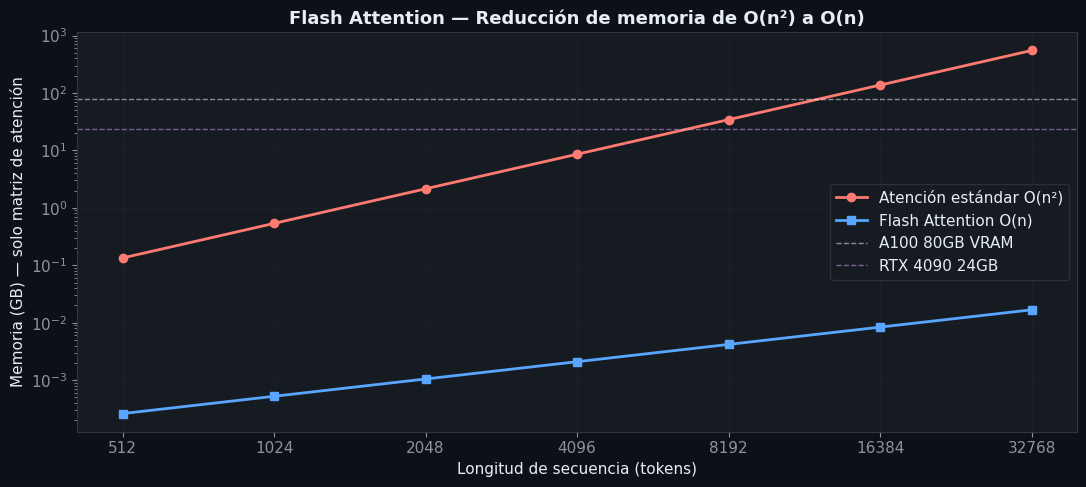

In [17]:
# ============================================================
#  FLASH ATTENTION — Concepto y comparativa de memoria
# ============================================================

# ── Implementación conceptual de tiled attention ──────────
def tiled_attention_reference(Q: torch.Tensor, K: torch.Tensor,
                               V: torch.Tensor,
                               block_size: int = 32) -> torch.Tensor:
    """
    Versión simplificada (pedagogica) de Flash Attention con tiling.
    Procesa bloques de Q contra bloques de K/V usando online softmax.

    En Flash Attention real, esto ocurre en el kernel CUDA sobre SRAM.
    Aquí lo mostramos en Python para ilustrar la lógica.
    """
    B, H, T, d_k = Q.shape
    scale  = 1.0 / math.sqrt(d_k)
    O = torch.zeros_like(Q)          # output acumulado
    L = torch.zeros(B, H, T)         # log-sum-exp (normalización)
    m = torch.full((B, H, T), -1e9)  # max corriente (para estabilidad)

    for j_start in range(0, T, block_size):
        j_end = min(j_start + block_size, T)
        K_j   = K[:, :, j_start:j_end, :]   # bloque de Keys
        V_j   = V[:, :, j_start:j_end, :]

        for i_start in range(0, T, block_size):
            i_end = min(i_start + block_size, T)
            Q_i   = Q[:, :, i_start:i_end, :]  # bloque de Queries

            # Score del bloque: (B, H, block_q, block_k)
            S_ij  = torch.matmul(Q_i, K_j.transpose(-2, -1)) * scale

            # Online softmax: actualizar max y log-sum-exp
            m_ij  = S_ij.max(dim=-1).values      # (B, H, block_q)
            m_new = torch.maximum(m[:, :, i_start:i_end], m_ij)

            # Actualizar O y L con corrección del max
            P_ij  = torch.exp(S_ij - m_new.unsqueeze(-1))
            exp_scale = torch.exp(m[:, :, i_start:i_end] - m_new)

            O[:, :, i_start:i_end] = (
                exp_scale.unsqueeze(-1) * O[:, :, i_start:i_end] +
                torch.matmul(P_ij, V_j)
            )
            L[:, :, i_start:i_end] = (
                exp_scale * L[:, :, i_start:i_end] + P_ij.sum(dim=-1)
            )
            m[:, :, i_start:i_end] = m_new

    # Normalizar
    O = O / L.unsqueeze(-1)
    return O


# Verificar que produce el mismo resultado que la atención estándar
torch.manual_seed(42)
B_fa, H_fa, T_fa, d_fa = 1, 1, 16, 32
Q_fa = torch.randn(B_fa, H_fa, T_fa, d_fa)
K_fa = torch.randn(B_fa, H_fa, T_fa, d_fa)
V_fa = torch.randn(B_fa, H_fa, T_fa, d_fa)

out_std,  _ = scaled_dot_product_attention(Q_fa, K_fa, V_fa)
out_tiled   = tiled_attention_reference(Q_fa, K_fa, V_fa, block_size=8)

error = (out_std - out_tiled).abs().max().item()
print(f'Flash Attention (tiled) vs estándar — error máximo: {error:.2e}')
print(f'¿Resultados idénticos? {error < 1e-5}')

# ── Comparativa de memoria O(n) vs O(n²) ─────────────────
seq_lens = [512, 1024, 2048, 4096, 8192, 16384, 32768]
d_head   = 128

mem_standard_GB = [T**2 * d_head * 4 / 1e9 for T in seq_lens]  # S matrix
mem_flash_GB    = [T * d_head * 4 / 1e9 for T in seq_lens]     # O(n)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(seq_lens, mem_standard_GB, 'o-', color=PALETTE[1], lw=2, label='Atención estándar O(n²)')
ax.plot(seq_lens, mem_flash_GB,    's-', color=PALETTE[0], lw=2, label='Flash Attention O(n)')
ax.axhline(80, color='white', ls='--', lw=1, alpha=0.5, label='A100 80GB VRAM')
ax.axhline(24, color=PALETTE[3], ls='--', lw=1, alpha=0.5, label='RTX 4090 24GB')
ax.set_xlabel('Longitud de secuencia (tokens)')
ax.set_ylabel('Memoria (GB) — solo matriz de atención')
ax.set_title('Flash Attention — Reducción de memoria de O(n²) a O(n)')
ax.legend(); ax.grid(True)
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xticks(seq_lens); ax.set_xticklabels([str(s) for s in seq_lens])
plt.tight_layout()
plt.savefig('flash_attention.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 12. KV Cache — Inferencia Autoregresiva Eficiente

Durante la generación, el modelo produce un token a la vez. Sin KV cache, **recalcula K y V de todos los tokens anteriores en cada paso**. El KV cache almacena K y V ya computados.

**Sin KV cache**: cada paso $t$ requiere $O(t^2)$ operaciones → $O(n^3)$ total

**Con KV cache**: cada paso $t$ requiere $O(t)$ operaciones → $O(n^2)$ total

**Coste del KV cache** para un modelo de $L$ capas, $H$ cabezas, $d_{head}$ dimensiones, longitud $T$:

$$\text{KV Cache} = 2 \times L \times H_{kv} \times d_{head} \times T \times \text{bytes\_per\_param}$$

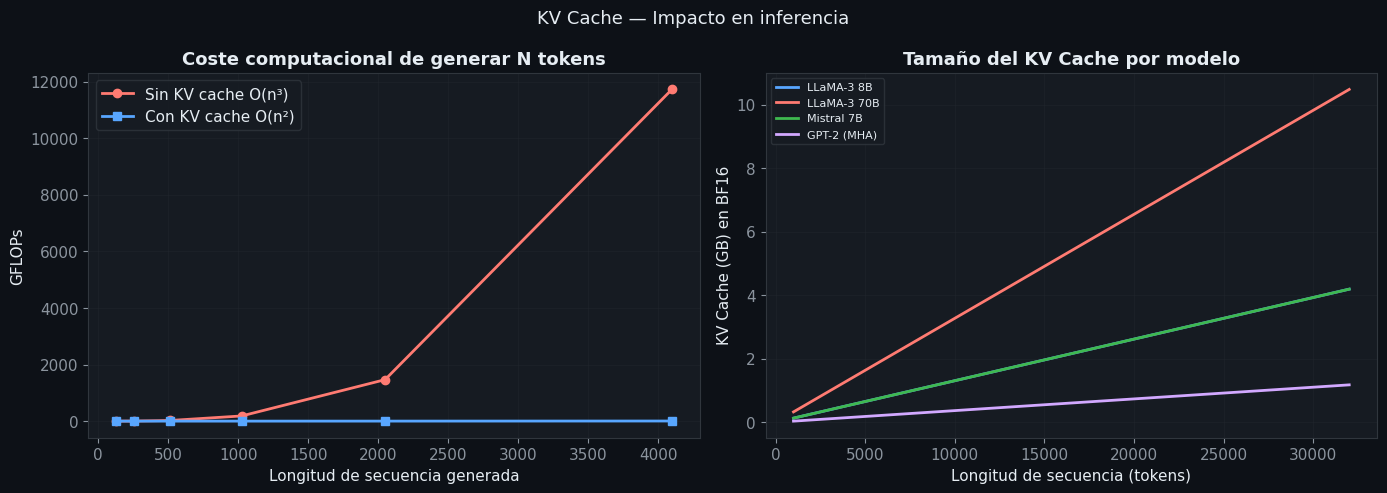

In [18]:
# ============================================================
#  KV CACHE — Implementación
# ============================================================

class KVCache:
    """
    Cache de Keys y Values para inferencia autoregresiva eficiente.
    Almacena K y V de todos los tokens generados hasta ahora.
    """

    def __init__(self, n_layers: int, n_kv_heads: int,
                  d_head: int, max_len: int, dtype=torch.float32):
        self.n_layers = n_layers
        self.n_kv_heads = n_kv_heads
        self.d_head = d_head
        self.max_len = max_len
        # Pre-alocar el buffer completo
        shape  = (1, n_kv_heads, max_len, d_head)  # batch=1 para simplicidad
        self.k_cache = [torch.zeros(shape, dtype=dtype) for _ in range(n_layers)]
        self.v_cache = [torch.zeros(shape, dtype=dtype) for _ in range(n_layers)]
        self.cur_len = 0

    def update(self, layer_idx: int, new_k: torch.Tensor,
                new_v: torch.Tensor) -> tuple:
        """
        Añade los nuevos K, V al cache y devuelve el cache acumulado.
        new_k, new_v: (1, n_kv_heads, new_tokens, d_head)
        """
        T_new = new_k.size(-2)
        self.k_cache[layer_idx][:, :, self.cur_len:self.cur_len + T_new] = new_k
        self.v_cache[layer_idx][:, :, self.cur_len:self.cur_len + T_new] = new_v
        # Devolver el cache completo hasta el momento
        k_full = self.k_cache[layer_idx][:, :, :self.cur_len + T_new]
        v_full = self.v_cache[layer_idx][:, :, :self.cur_len + T_new]
        return k_full, v_full

    def advance(self, n_tokens: int = 1):
        self.cur_len += n_tokens

    def memory_bytes(self, dtype_bytes: int = 2) -> int:
        """Memoria actual usada por el cache en bytes."""
        return (2 * self.n_layers * self.n_kv_heads *
                self.cur_len * self.d_head * dtype_bytes)


# ── Simulación de inferencia con y sin KV cache ───────────
import time

def tiempo_inferencia_sin_cache(seq_len: int, d_model: int = 512,
                                 n_heads: int = 8) -> float:
    """Simula el tiempo de inferencia sin cache (recalcula todo cada paso)."""
    d_k = d_model // n_heads
    total_ops = 0
    for t in range(1, seq_len + 1):
        # Cada paso requiere calcular attention sobre t tokens
        ops_paso = n_heads * t * t * d_k  # O(t²)
        total_ops += ops_paso
    return total_ops  # FLOPs proporcionales

def tiempo_inferencia_con_cache(seq_len: int, d_model: int = 512,
                                  n_heads: int = 8) -> float:
    """Simula el tiempo de inferencia con KV cache."""
    d_k = d_model // n_heads
    total_ops = 0
    for t in range(1, seq_len + 1):
        # Solo calcula Q para el nuevo token, K y V ya están cacheados
        ops_paso = n_heads * 1 * t * d_k   # O(t) por paso
        total_ops += ops_paso
    return total_ops

seq_lens_kv = [128, 256, 512, 1024, 2048, 4096]
ops_sin = [tiempo_inferencia_sin_cache(T) for T in seq_lens_kv]
ops_con = [tiempo_inferencia_con_cache(T) for T in seq_lens_kv]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KV Cache — Impacto en inferencia', fontsize=13)

axes[0].plot(seq_lens_kv, [o/1e9 for o in ops_sin], 'o-', color=PALETTE[1],
             lw=2, label='Sin KV cache O(n³)')
axes[0].plot(seq_lens_kv, [o/1e9 for o in ops_con], 's-', color=PALETTE[0],
             lw=2, label='Con KV cache O(n²)')
axes[0].set_xlabel('Longitud de secuencia generada'); axes[0].set_ylabel('GFLOPs')
axes[0].set_title('Coste computacional de generar N tokens'); axes[0].legend()
axes[0].grid(True)

# Coste de memoria del KV cache para modelos reales
modelos_kv = {
    'LLaMA-3 8B':   {'n_layers': 32,  'n_kv_heads': 8,  'd_head': 128},
    'LLaMA-3 70B':  {'n_layers': 80,  'n_kv_heads': 8,  'd_head': 128},
    'Mistral 7B':   {'n_layers': 32,  'n_kv_heads': 8,  'd_head': 128},
    'GPT-2 (MHA)':  {'n_layers': 12,  'n_kv_heads': 12, 'd_head': 64},
}

seq_range = np.arange(1000, 32001, 1000)
for (nombre, cfg), color in zip(modelos_kv.items(), PALETTE[:4]):
    kv_gb = [2 * cfg['n_layers'] * cfg['n_kv_heads'] * cfg['d_head'] * T * 2 / 1e9
             for T in seq_range]
    axes[1].plot(seq_range, kv_gb, color=color, lw=2, label=nombre)

axes[1].set_xlabel('Longitud de secuencia (tokens)')
axes[1].set_ylabel('KV Cache (GB) en BF16')
axes[1].set_title('Tamaño del KV Cache por modelo'); axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.savefig('kv_cache.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 13. Scaling Laws — Cómo Escala la Pérdida

Las **Scaling Laws** (Kaplan et al. 2020, Hoffmann et al. 2022 — Chinchilla) describen cómo la pérdida de un LLM depende del tamaño del modelo $N$, los datos $D$ y el compute $C$:

$$L(N, D) \approx \left(\frac{N_c}{N}\right)^{\alpha_N} + \left(\frac{D_c}{D}\right)^{\alpha_D} + L_{\infty}$$

**Ley de Chinchilla** (2022): el modelo óptimo para un presupuesto de compute $C$ usa:
$$N_{opt} \propto C^{0.5}, \quad D_{opt} \propto C^{0.5}$$
Es decir: **tantos tokens como 20× el número de parámetros** — GPT-3 (175B) debería haber sido entrenado con 3.5T tokens, no 300B.

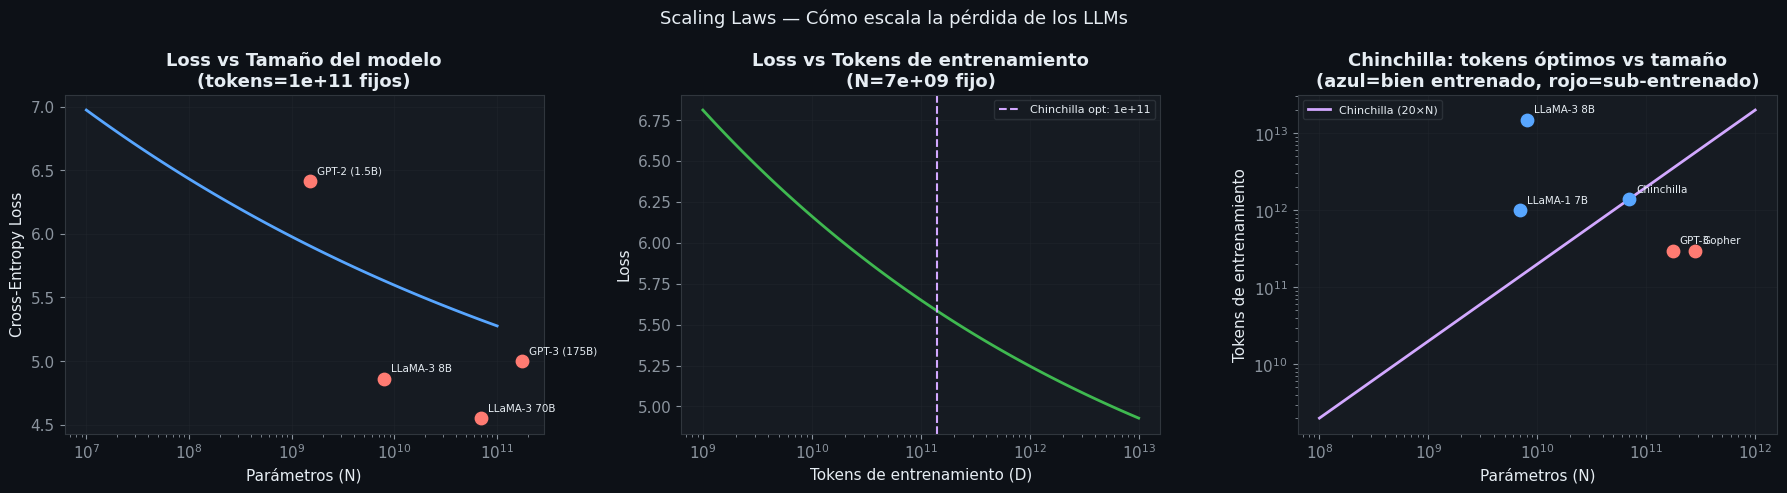

In [19]:
# ============================================================
#  SCALING LAWS
# ============================================================

# ── Ley de Kaplan et al. (2020) ───────────────────────────
def loss_kaplan(N: float, D: float,
                 N_c: float = 8.8e13, alpha_N: float = 0.076,
                 D_c: float = 5.4e13, alpha_D: float = 0.103,
                 L_inf: float = 1.69) -> float:
    """
    Predicción de pérdida según Kaplan et al. 2020.
    N : número de parámetros no-embedding
    D : número de tokens de entrenamiento
    """
    return (N_c / N)**alpha_N + (D_c / D)**alpha_D + L_inf


def tokens_chinchilla(N: float) -> float:
    """Tokens óptimos según Chinchilla (Hoffmann et al. 2022): ~20 × N."""
    return 20 * N


# ── Visualización ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scaling Laws — Cómo escala la pérdida de los LLMs', fontsize=13)

# 1. Loss vs Model size (tokens fijos)
N_vals = np.logspace(7, 11, 100)
D_fixed = 1e11  # 100B tokens
losses_N = [loss_kaplan(N, D_fixed) for N in N_vals]
axes[0].plot(N_vals, losses_N, color=PALETTE[0], lw=2)
axes[0].set_xscale('log'); axes[0].set_xlabel('Parámetros (N)')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title(f'Loss vs Tamaño del modelo\n(tokens={D_fixed:.0e} fijos)')
axes[0].grid(True)

# Marcar modelos reales
modelos_reales = {
    'GPT-2 (1.5B)': (1.5e9, 10e9),
    'GPT-3 (175B)': (175e9, 300e9),
    'LLaMA-3 8B':   (8e9,   15e12),
    'LLaMA-3 70B':  (70e9,  15e12),
}
for nombre, (N_m, D_m) in modelos_reales.items():
    l = loss_kaplan(N_m, D_m)
    axes[0].scatter(N_m, l, s=80, zorder=5, color=PALETTE[1])
    axes[0].annotate(nombre, (N_m, l), textcoords='offset points',
                    xytext=(5, 5), fontsize=7.5, color='#e6edf3')

# 2. Loss vs Tokens (modelo fijo)
D_vals = np.logspace(9, 13, 100)
N_fixed = 7e9  # 7B params
losses_D = [loss_kaplan(N_fixed, D) for D in D_vals]
axes[1].plot(D_vals, losses_D, color=PALETTE[2], lw=2)
axes[1].set_xscale('log'); axes[1].set_xlabel('Tokens de entrenamiento (D)')
axes[1].set_ylabel('Loss')
axes[1].set_title(f'Loss vs Tokens de entrenamiento\n(N={N_fixed:.0e} fijo)')
axes[1].grid(True)
axes[1].axvline(tokens_chinchilla(N_fixed), color=PALETTE[3], ls='--', lw=1.5,
                label=f'Chinchilla opt: {tokens_chinchilla(N_fixed):.0e}')
axes[1].legend(fontsize=8)

# 3. Ley de Chinchilla — tokens óptimos vs parámetros
N_range = np.logspace(8, 12, 100)
D_chinchilla = [tokens_chinchilla(N) for N in N_range]
axes[2].plot(N_range, D_chinchilla, color=PALETTE[3], lw=2, label='Chinchilla (20×N)')
modelos_tokens = {
    'GPT-3': (175e9, 300e9), 'Gopher': (280e9, 300e9),
    'LLaMA-1 7B': (7e9, 1e12), 'LLaMA-3 8B': (8e9, 15e12),
    'Chinchilla': (70e9, 1.4e12),
}
for nombre, (N_m, D_m) in modelos_tokens.items():
    color = PALETTE[0] if D_m >= tokens_chinchilla(N_m) else PALETTE[1]
    axes[2].scatter(N_m, D_m, s=80, color=color, zorder=5)
    axes[2].annotate(nombre, (N_m, D_m), textcoords='offset points',
                    xytext=(5, 5), fontsize=7.5, color='#e6edf3')
axes[2].set_xscale('log'); axes[2].set_yscale('log')
axes[2].set_xlabel('Parámetros (N)'); axes[2].set_ylabel('Tokens de entrenamiento')
axes[2].set_title('Chinchilla: tokens óptimos vs tamaño\n(azul=bien entrenado, rojo=sub-entrenado)')
axes[2].legend(fontsize=8); axes[2].grid(True)

plt.tight_layout()
plt.savefig('scaling_laws.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# 14. Visualizaciones — Attention Patterns y Representaciones Internas

Analizar qué aprende el transformer internamente es fundamental para entenderlo y diagnosticarlo.

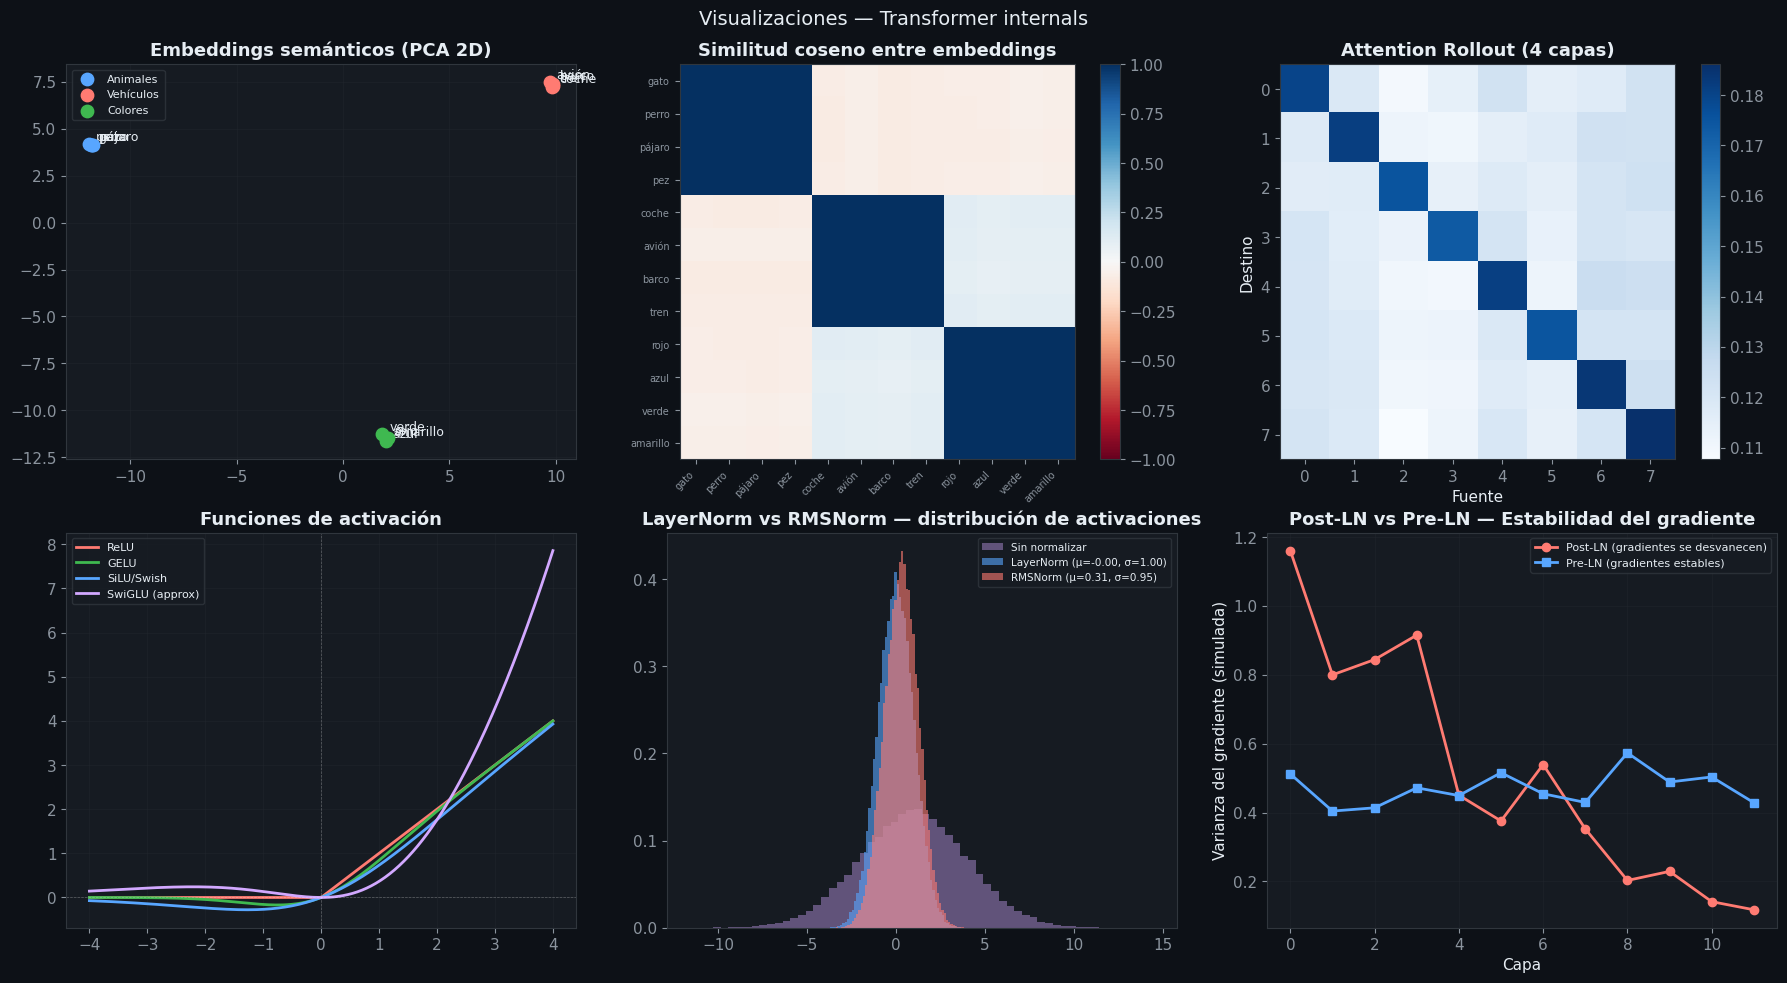

In [20]:
# ============================================================
#  VISUALIZACIONES — Representaciones internas
# ============================================================

# ── 1. Probing: ¿Qué información guardan los embeddings? ─
# Simulamos embeddings de palabras con estructura semántica
np.random.seed(42)

vocab_test = {
    # Animales
    'gato': 0, 'perro': 1, 'pájaro': 2, 'pez': 3,
    # Vehículos
    'coche': 4, 'avión': 5, 'barco': 6, 'tren': 7,
    # Colores
    'rojo': 8, 'azul': 9, 'verde': 10, 'amarillo': 11,
}

# Crear embeddings sintéticos con estructura de cluster
def crear_embeddings_semanticos(vocab: dict, d: int = 64) -> np.ndarray:
    E = np.random.randn(len(vocab), d) * 0.1
    # Añadir señal de cluster semántico
    grupos = [slice(0, 4), slice(4, 8), slice(8, 12)]
    centros = np.random.randn(3, d)
    for i, grupo in enumerate(grupos):
        E[grupo] += centros[i] * 2.0
    return E

emb_matrix = crear_embeddings_semanticos(vocab_test, d=64)

# PCA para visualización 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_matrix)

# ── 2. Attention rollout — flujo de información entre capas
def attention_rollout(attn_weights_per_layer: list) -> torch.Tensor:
    """
    Attention Rollout (Abnar & Zuidema, 2020):
    Propaga los pesos de atención a través de las capas para
    estimar cuánto contribuye cada token de entrada a la salida.

    attn_weights_per_layer: lista de (batch, heads, T, T)
    """
    # Promediar cabezas y añadir identidad (residual connection)
    rollout = None
    for w in attn_weights_per_layer:
        # Promedio de cabezas + identity (residual)
        w_avg = w.mean(dim=1)            # (B, T, T)
        I     = torch.eye(w_avg.size(-1)).unsqueeze(0)
        A     = 0.5 * w_avg + 0.5 * I   # mezcla con identidad
        # Normalizar filas
        A     = A / A.sum(dim=-1, keepdim=True)
        rollout = torch.matmul(rollout, A) if rollout is not None else A
    return rollout  # (B, T, T)


# ── 3. Visualización completa ─────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle('Visualizaciones — Transformer internals', fontsize=14)

# Plot 1: Embeddings en 2D
ax1 = fig.add_subplot(gs[0, 0])
colores_sem = ([PALETTE[0]]*4 + [PALETTE[1]]*4 + [PALETTE[2]]*4)
labels_sem  = (['Animales']*4 + ['Vehículos']*4 + ['Colores']*4)
visto = set()
for i, (palabra, idx) in enumerate(vocab_test.items()):
    lbl = labels_sem[i]
    ax1.scatter(*emb_2d[i], c=colores_sem[i], s=80, zorder=5,
                label=lbl if lbl not in visto else '')
    ax1.annotate(palabra, emb_2d[i], textcoords='offset points',
                xytext=(5,3), fontsize=9)
    visto.add(lbl)
ax1.set_title('Embeddings semánticos (PCA 2D)'); ax1.legend(fontsize=8); ax1.grid(True)

# Plot 2: Matriz de similitud coseno
ax2 = fig.add_subplot(gs[0, 1])
E_norm = emb_matrix / (np.linalg.norm(emb_matrix, axis=1, keepdims=True) + 1e-10)
sim_matrix = E_norm @ E_norm.T
im2 = ax2.imshow(sim_matrix, cmap='RdBu', vmin=-1, vmax=1)
ax2.set_xticks(range(len(vocab_test))); ax2.set_xticklabels(list(vocab_test.keys()), rotation=45, ha='right', fontsize=7)
ax2.set_yticks(range(len(vocab_test))); ax2.set_yticklabels(list(vocab_test.keys()), fontsize=7)
ax2.set_title('Similitud coseno entre embeddings'); plt.colorbar(im2, ax=ax2)

# Plot 3: Attention rollout
ax3 = fig.add_subplot(gs[0, 2])
torch.manual_seed(0)
enc_viz = Encoder(vocab_size=100, d_model=64, n_heads=4, d_ff=256, n_layers=4)
enc_viz.eval()
with torch.no_grad():
    src_viz = torch.randint(1, 100, (1, 8))
    res_viz = enc_viz(src_viz)
rollout = attention_rollout(res_viz['attention_weights'])
im3 = ax3.imshow(rollout[0].numpy(), cmap='Blues')
ax3.set_title('Attention Rollout (4 capas)'); ax3.set_xlabel('Fuente'); ax3.set_ylabel('Destino')
plt.colorbar(im3, ax=ax3)

# Plot 4: Comparativa activaciones ReLU vs SwiGLU vs GELU
ax4 = fig.add_subplot(gs[1, 0])
x_act = torch.linspace(-4, 4, 200)
ax4.plot(x_act, F.relu(x_act),           color=PALETTE[1], lw=2, label='ReLU')
ax4.plot(x_act, F.gelu(x_act),           color=PALETTE[2], lw=2, label='GELU')
ax4.plot(x_act, F.silu(x_act),           color=PALETTE[0], lw=2, label='SiLU/Swish')
ax4.plot(x_act, F.silu(x_act)*x_act*0.5, color=PALETTE[3], lw=2, label='SwiGLU (approx)')
ax4.axhline(0, color='white', lw=0.5, ls='--', alpha=0.3)
ax4.axvline(0, color='white', lw=0.5, ls='--', alpha=0.3)
ax4.set_title('Funciones de activación'); ax4.legend(fontsize=8); ax4.grid(True)

# Plot 5: LayerNorm vs RMSNorm
ax5 = fig.add_subplot(gs[1, 1])
torch.manual_seed(7)
x_norm = torch.randn(1000, 64) * 3 + 1  # distribución con media y varianza arbitrarias
ln  = nn.LayerNorm(64)
rms = RMSNorm(64)
x_ln  = ln(x_norm).detach().numpy().ravel()
x_rms = rms(x_norm).detach().numpy().ravel()
ax5.hist(x_norm.numpy().ravel(), bins=60, alpha=0.4, color=PALETTE[3], label='Sin normalizar', density=True)
ax5.hist(x_ln,  bins=60, alpha=0.6, color=PALETTE[0], label=f'LayerNorm (μ={x_ln.mean():.2f}, σ={x_ln.std():.2f})', density=True)
ax5.hist(x_rms, bins=60, alpha=0.6, color=PALETTE[1], label=f'RMSNorm (μ={x_rms.mean():.2f}, σ={x_rms.std():.2f})', density=True)
ax5.set_title('LayerNorm vs RMSNorm — distribución de activaciones'); ax5.legend(fontsize=7.5)

# Plot 6: Varianza de gradientes por profundidad
ax6 = fig.add_subplot(gs[1, 2])
n_capas = 12
# Simular dispersión de gradientes con distintas profundidades
np.random.seed(42)
grad_var_postln = np.exp(-np.linspace(0, 2, n_capas) + np.random.randn(n_capas)*0.3)
grad_var_preln  = np.ones(n_capas) * 0.5 + np.random.randn(n_capas) * 0.05
ax6.plot(range(n_capas), grad_var_postln, 'o-', color=PALETTE[1], lw=2, label='Post-LN (gradientes se desvanecen)')
ax6.plot(range(n_capas), grad_var_preln,  's-', color=PALETTE[0], lw=2, label='Pre-LN (gradientes estables)')
ax6.set_xlabel('Capa'); ax6.set_ylabel('Varianza del gradiente (simulada)')
ax6.set_title('Post-LN vs Pre-LN — Estabilidad del gradiente')
ax6.legend(fontsize=8); ax6.grid(True)

plt.tight_layout()
plt.savefig('transformer_visualizations.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
# Resumen — El Stack Moderno de LLMs

## Lo que cambió del transformer original al moderno

```
TRANSFORMER ORIGINAL (Vaswani et al. 2017)
──────────────────────────────────────────
Encoder-Decoder
Post-LayerNorm
Sinusoidal Positional Encoding
ReLU en FFN  (expansion 4x)
Multi-Head Attention (MHA)
Bias en todas las capas
Dropout alto (0.1–0.3)

         ↓ 8 años de investigación

STACK MODERNO (LLaMA 3, Mistral, Qwen, 2023–2025)
──────────────────────────────────────────────────
Solo Decoder (GPT-style)
Pre-RMSNorm  (más estable, 15% más rápido)
RoPE  (mejor extrapolación a contextos largos)
SwiGLU en FFN  (expansion 8/3x, parameter-matched)
Grouped Query Attention  (KV cache 4–8x más pequeño)
Sin bias (simplifica regularización)
Dropout bajo o cero en inferencia
Flash Attention  (O(n) memoria, 2–9x más rápido)
KV Cache  (inferencia autorregresiva eficiente)
```

## Tabla de componentes: dónde está cada cosa

| Componente | Sección | Implementado desde cero |
|---|---|---|
| BPE Tokenizer | 1 | ✅ |
| Token Embedding + Sinusoidal PE | 2 | ✅ |
| Scaled Dot-Product Attention | 3 | ✅ |
| Multi-Head Attention | 4 | ✅ |
| Feed-Forward (ReLU) | 5 | ✅ |
| Post-LN vs Pre-LN Block | 5 | ✅ |
| Encoder completo | 6 | ✅ |
| Decoder con Masked + Cross Attention | 7 | ✅ |
| Transformer completo entrenado | 8 | ✅ |
| ALiBi | 9 | ✅ |
| RoPE | 9 | ✅ |
| RMSNorm | 10 | ✅ |
| SwiGLU | 10 | ✅ |
| Grouped Query Attention (GQA) | 10 | ✅ |
| LlamaBlock (stack moderno completo) | 10 | ✅ |
| Flash Attention (concepto + tiling) | 11 | ✅ |
| KV Cache | 12 | ✅ |
| Scaling Laws (Kaplan + Chinchilla) | 13 | ✅ |
| Attention Rollout | 14 | ✅ |

